In [1]:
# # Validation — Robust SBB Journey Planner
#
# Four validation sections:
#   1. Algorithm smoke test — does it return routes at all?
#   2. Sanity checks       — Q=0% deterministic, Q=100% conservative, monotonicity
#   3. Delay model calibration — predicted vs empirical CDF on held-out Istdaten
#   4. Backtest            — empirical success rate vs claimed confidence level


In [2]:
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pyspark.sql import functions as F
 
from demo_app import setup
 
spark, data, planner = setup(force_recompute = True)



Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/21 17:39:07 WARN Utils: Service 'SparkUI' could not bind on port 4170. Attempting port 4171.
26/05/21 17:39:18 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


force_recompute=True — skipping cache, running full data preparation...


26/05/21 17:40:42 WARN DAGScheduler: Broadcasting large task binary with size 1049.0 KiB
26/05/21 17:41:10 WARN DAGScheduler: Broadcasting large task binary with size 1207.4 KiB
26/05/21 17:41:14 WARN DAGScheduler: Broadcasting large task binary with size 1422.8 KiB
26/05/21 17:41:25 WARN DAGScheduler: Broadcasting large task binary with size 1217.1 KiB
26/05/21 17:41:25 WARN DAGScheduler: Broadcasting large task binary with size 1213.9 KiB
26/05/21 17:41:29 WARN DAGScheduler: Broadcasting large task binary with size 1246.2 KiB
26/05/21 17:41:33 WARN DAGScheduler: Broadcasting large task binary with size 1461.7 KiB
26/05/21 17:41:45 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Loaded 390 stops


26/05/21 17:45:49 WARN DAGScheduler: Broadcasting large task binary with size 1249.7 KiB
26/05/21 17:45:49 WARN DAGScheduler: Broadcasting large task binary with size 1256.0 KiB
26/05/21 17:45:52 WARN DAGScheduler: Broadcasting large task binary with size 1254.4 KiB


Loaded 922769 connections
Loaded walking edges for 382 stops


Loaded DelayLookup with empirical distributions
Loaded fallback delay features for 8610 (stop, hour) pairs


In [3]:
# Use the first two stops alphabetically by name as a safe default
sorted_stops = sorted(planner.stops.items(), key=lambda x: x[1]['name'])
ORIGIN_ID      = sorted_stops[0][0]
DESTINATION_ID = sorted_stops[1][0]
print(f"Origin:      {ORIGIN_ID}  {planner.stops[ORIGIN_ID]['name']}")
print(f"Destination: {DESTINATION_ID}  {planner.stops[DESTINATION_ID]['name']}")
TEST_DAY        = "tuesday"
TEST_ARRIVES_BY = "09:00"
 
fmt = lambda s: f"{s // 3600:02d}:{(s % 3600) // 60:02d}"
 
print(f"\nStops loaded:       {len(planner.stops)}")
print(f"Connections loaded: {len(planner.conn_arr)}")
print(f"Walking edges:      {len(planner.walking)} stops")
print(f"DelayLookup:        {'loaded' if planner.delay_lookup else 'not loaded (Normal fallback)'}")


Origin:      8501170  Bel-Air LEB
Destination: 8501117  Bussigny

Stops loaded:       390
Connections loaded: 922769
Walking edges:      382 stops
DelayLookup:        loaded


### Basic Route Display

In [4]:
# Confirms the algorithm returns routes for a concrete query and
# prints them in human-readable form. Timing is shown.
 

print("SMOKE TEST — routes() output")

print(f"  From:       {planner.stops.get(ORIGIN_ID, {}).get('name', ORIGIN_ID)}")
print(f"  To:         {planner.stops.get(DESTINATION_ID, {}).get('name', DESTINATION_ID)}")
print(f"  Arrive by:  {TEST_ARRIVES_BY} on {TEST_DAY}")
print(f"  Confidence: 80%\n")
 
t0     = time.perf_counter()
routes = planner.routes(
    ORIGIN_ID, DESTINATION_ID,
    arrives_by=TEST_ARRIVES_BY,
    day=TEST_DAY,
    confidence_threshold=0.80,
    max_routes=5,
)
elapsed = time.perf_counter() - t0
 
if not routes:
    print("No routes found — check stop IDs and timetable coverage.")
else:
    print(f"Found {len(routes)} route(s) in {elapsed*1000:.1f}ms\n")
    for i, r in enumerate(routes, 1):
        print(f"Route {i}:")
        planner.describe_route(r)
        print()


SMOKE TEST — routes() output
  From:       Bel-Air LEB
  To:         Bussigny
  Arrive by:  09:00 on tuesday
  Confidence: 80%

Found 5 route(s) in 2797.8ms

Route 1:
Departure 08:03 → Arrival 08:48  (confidence 96%, 2 transfer(s), 473m walking)
  08:03  board  392.TA.91-20-I-j26-1.10.R  at Bel-Air LEB
  08:05  alight at Vernand-Camarès
  08:05  board  392.TA.91-20-I-j26-1.10.R  at Vernand-Camarès
  08:06  alight at Romanel-sur-Lausanne
  08:07  board  392.TA.91-20-I-j26-1.10.R  at Romanel-sur-Lausanne
  08:09  alight at Jouxtens-Mézery
  08:09  board  392.TA.91-20-I-j26-1.10.R  at Jouxtens-Mézery
  08:10  alight at Cery-Fleur-de-Lys
  08:10  board  392.TA.91-20-I-j26-1.10.R  at Cery-Fleur-de-Lys
  08:12  alight at Prilly-Chasseur
  08:19  walk   Prilly-Chasseur → Prilly, Chasseur
  08:20  board  483.TA.92-33-G-j26-1.2.R  at Prilly, Chasseur
  08:22  alight at Prilly, centre
  08:22  board  483.TA.92-33-G-j26-1.2.R  at Prilly, centre
  08:24  alight at Prilly, Grand Vigne
  08:24  boar

### a. Sanity check — Q=0% equals deterministic
With confidence_threshold=0, the planner treats all connections as on-time.
The best departure must be >= the Q=80% best departure (deterministic is fastest).


In [5]:
routes_det = planner.routes(
    ORIGIN_ID, DESTINATION_ID,
    arrives_by=TEST_ARRIVES_BY,
    day=TEST_DAY,
    confidence_threshold=0.0,
    max_routes=1,
)
routes_q80 = planner.routes(
    ORIGIN_ID, DESTINATION_ID,
    arrives_by=TEST_ARRIVES_BY,
    day=TEST_DAY,
    confidence_threshold=0.80,
    max_routes=1,
)
 
if routes_det:
    r = routes_det[0]
    print(f"  Q=0%  departs {fmt(r['dep_time'])}, confidence={r['confidence']:.0%}, "
          f"transfers={r['n_transfers']}")
else:
    print("  Q=0%  → no route found")
 
if routes_q80:
    r = routes_q80[0]
    print(f"  Q=80% departs {fmt(r['dep_time'])}, confidence={r['confidence']:.0%}, "
          f"transfers={r['n_transfers']}")
else:
    print("  Q=80% → no route found")
 
if routes_det and routes_q80:
    det_dep = routes_det[0]['dep_time']
    q80_dep = routes_q80[0]['dep_time']
    print(f"\n  {'✓ PASS' if det_dep >= q80_dep else '✗ FAIL'}: "
          f"Q=0% departs {'same time or later' if det_dep >= q80_dep else 'earlier'} than Q=80%")


  Q=0%  departs 08:10, confidence=86%, transfers=3
  Q=80% departs 08:03, confidence=96%, transfers=2

  ✓ PASS: Q=0% departs same time or later than Q=80%


  Q=0%  → departs 08:10, confidence=86%
  Q=50%  → departs 08:10, confidence=54%
  Q=70%  → departs 08:10, confidence=73%
  Q=80%  → departs 08:03, confidence=96%
  Q=90%  → departs 08:03, confidence=96%
  Q=95%  → departs 08:03, confidence=96%

  ✓ PASS: departure time is non-increasing as Q increases


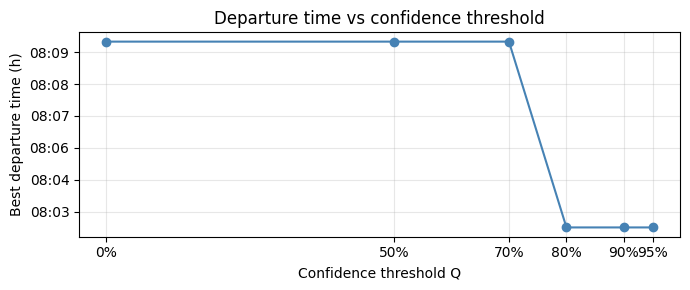

In [6]:
# monotonicity of departure time vs Q 
# As Q increases the planner must be more conservative:
# best departure time must be non-increasing.
 

q_levels  = [0.0, 0.5, 0.7, 0.8, 0.9, 0.95]
dep_times = []
 
for q in q_levels:
    rs = planner.routes(
        ORIGIN_ID, DESTINATION_ID,
        arrives_by=TEST_ARRIVES_BY,
        day=TEST_DAY,
        confidence_threshold=q,
        max_routes=1,
    )
    if rs:
        dep_times.append(rs[0]['dep_time'])
        print(f"  Q={q:.0%}  → departs {fmt(rs[0]['dep_time'])}, "
              f"confidence={rs[0]['confidence']:.0%}")
    else:
        dep_times.append(None)
        print(f"  Q={q:.0%}  → no route found")
 
valid = [(q, d) for q, d in zip(q_levels, dep_times) if d is not None]
mono_ok = all(valid[i][1] >= valid[i+1][1] for i in range(len(valid)-1))
print(f"\n  {'✓ PASS' if mono_ok else '✗ FAIL'}: departure time is "
      f"{'non-increasing' if mono_ok else 'NOT non-increasing'} as Q increases")
 
fig, ax = plt.subplots(figsize=(7, 3))
qs_plot = [q for q, d in zip(q_levels, dep_times) if d is not None]
dt_plot = [d / 3600 for d in dep_times if d is not None]
ax.plot(qs_plot, dt_plot, marker='o', color='steelblue')
ax.set_xlabel("Confidence threshold Q")
ax.set_ylabel("Best departure time (h)")
ax.set_title("Departure time vs confidence threshold")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"{int(v):02d}:{int((v % 1) * 60):02d}")
)
ax.set_xticks(qs_plot)
ax.set_xticklabels([f"{q:.0%}" for q in qs_plot])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Q=100% is ultra-conservative or returns nothing

In [7]:
routes_100 = planner.routes(
    ORIGIN_ID, DESTINATION_ID,
    arrives_by=TEST_ARRIVES_BY,
    day=TEST_DAY,
    confidence_threshold=1.0,
    max_routes=3,
)
 
if not routes_100:
    print("  PASS: Q=100% returned no routes (threshold too strict — expected)")
else:
    all_certain = all(r['confidence'] >= 0.999 for r in routes_100)
    print(f"  Found {len(routes_100)} route(s) at Q=100%:")
    for r in routes_100:
        print(f"    departs {fmt(r['dep_time'])}, confidence={r['confidence']:.4%}, "
              f"transfers={r['n_transfers']}")
    print(f"\n  {'✓ PASS' if all_certain else '✗ FAIL'}: "
          f"all returned routes have confidence ≈ 100%")
 


  Found 2 route(s) at Q=100%:
    departs 06:03, confidence=100.0000%, transfers=2
    departs 05:49, confidence=100.0000%, transfers=2

  ✓ PASS: all returned routes have confidence ≈ 100%


### Delay model calibration : predicted vs empirical 
Hold out the last ~3 months of Istdaten (from 2025-11-01). <br>
Build distributions on the rest. <br>
Compare predicted P(delay <= x) against empirical frequency on holdout. <br>
Key output: calibration curve (predicted vs observed). <br>


  Train:   944 days  (< 2025-11-01)
  Holdout: 92 days (>= 2025-11-01)



  Evaluated on 50000 holdout observations


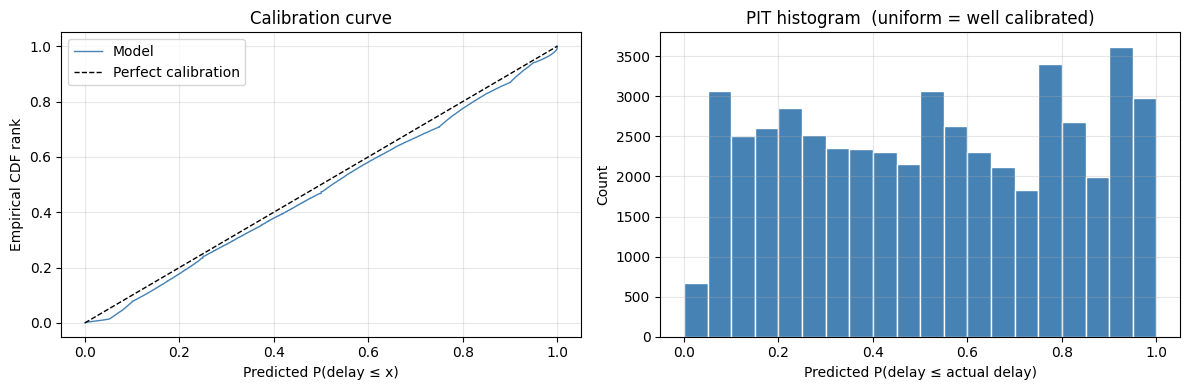

  KS statistic vs uniform: 0.0434  (p-value=0.0000)
  ✓ Well calibrated (KS < 0.05)

  Pinball loss per quantile (lower is better):
    quantile     pinball
        0.05      0.1669
        0.10      0.2910
        0.25      0.5749
        0.50      0.8594
        0.75      0.8753
        0.90      0.6301
        0.95      0.4458
        0.99      0.1820
        mean      0.5032

  Brier score at key thresholds (lower is better):
     threshold     brier
           0 min    0.1520
           2 min    0.1868
           5 min    0.0737
          10 min    0.0248

  Fallback level breakdown:
        bpuic_hour_dow   49980 / 50000  (100.0%)
            bpuic_hour      15 / 50000  (0.0%)
                 bpuic       5 / 50000  (0.0%)


In [8]:
SPLIT_DATE = "2025-11-01"  # fixed future holdout

if data.istdaten is None:
    print("  Skipped: no Istdaten loaded. Set start_date/end_date in demo_app.py.")
else:
    from data_prep import build_delay_training_table
    from delay_model import (
        build_delay_distribution_tables,
        collect_distribution_tables,
        DelayLookup,
        QUANTILES,
        DOW_BUCKET_WEEKDAY,
        DOW_BUCKET_SATURDAY,
        DOW_BUCKET_SUNDAY,
    )
    from scipy.stats import kstest
    from sklearn.metrics import mean_pinball_loss, brier_score_loss

    # --- train / holdout split at fixed date ---
    all_days = sorted(
        data.istdaten
        .select("operating_day").distinct()
        .toPandas()["operating_day"].tolist()
    )
    import datetime
    _split = datetime.date.fromisoformat(SPLIT_DATE)
    n_train   = len([d for d in all_days if d <  _split])
    n_holdout = len([d for d in all_days if d >= _split])
    print(f"  Train:   {n_train} days  (< {SPLIT_DATE})")
    print(f"  Holdout: {n_holdout} days (>= {SPLIT_DATE})")

    train_df   = data.istdaten.filter(F.col("operating_day") <  SPLIT_DATE)
    holdout_df = data.istdaten.filter(F.col("operating_day") >= SPLIT_DATE)

    levels       = build_delay_distribution_tables(build_delay_training_table(train_df))
    tables       = collect_distribution_tables(levels, min_observations=30)
    calib_lookup = DelayLookup.from_collected(tables)

    # Sample up to 50 000 holdout rows
    holdout_pd = (
        build_delay_training_table(holdout_df)
        .select("bpuic", "hour_of_day", "day_of_week", "product_id_clean", "line_text", "arr_delay_mins")
        .limit(50_000)
        .toPandas()
    )

    DOW_MAP      = {1: DOW_BUCKET_SUNDAY, 7: DOW_BUCKET_SATURDAY}
    BRIER_THRESH = [0, 2, 5, 10]

    rows_used      = []
    predicted_p    = []
    pred_quantiles = []
    brier_preds    = {t: [] for t in BRIER_THRESH}
    fallback_lvls  = []

    for idx, row in holdout_pd.iterrows():
        dow = DOW_MAP.get(int(row["day_of_week"]), DOW_BUCKET_WEEKDAY)
        try:
            dist = calib_lookup.get(
                bpuic      = int(row["bpuic"]),
                hour       = int(row["hour_of_day"]),
                dow_bucket = dow,
                product_id = row.get("product_id_clean"),
                line_text  = row.get("line_text"),
            )
            rows_used.append(idx)
            predicted_p.append(dist.cdf(float(row["arr_delay_mins"])))
            pred_quantiles.append(list(dist.qs))
            fallback_lvls.append(dist.source_level)
            for t in BRIER_THRESH:
                brier_preds[t].append(dist.cdf(t))
        except KeyError:
            pass

    predicted_p    = np.array(predicted_p)
    pred_quantiles = np.array(pred_quantiles)
    y_eval         = holdout_pd.loc[rows_used, "arr_delay_mins"].values
    print(f"\n  Evaluated on {len(predicted_p)} holdout observations")

    # --- 1. Calibration curve + KS ---
    sort_idx    = np.argsort(predicted_p)
    pred_sorted = predicted_p[sort_idx]
    emp_cdf     = np.arange(1, len(pred_sorted) + 1) / len(pred_sorted)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(pred_sorted, emp_cdf, color="steelblue", lw=1, label="Model")
    axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Perfect calibration")
    axes[0].set_xlabel("Predicted P(delay ≤ x)")
    axes[0].set_ylabel("Empirical CDF rank")
    axes[0].set_title("Calibration curve")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].hist(predicted_p, bins=20, color="steelblue", edgecolor="white")
    axes[1].set_xlabel("Predicted P(delay ≤ actual delay)")
    axes[1].set_ylabel("Count")
    axes[1].set_title("PIT histogram  (uniform = well calibrated)")
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    ks_stat, ks_p = kstest(predicted_p, "uniform")
    print(f"  KS statistic vs uniform: {ks_stat:.4f}  (p-value={ks_p:.4f})")
    print(f"  {'✓ Well calibrated (KS < 0.05)' if ks_stat < 0.05 else '⚠ Some miscalibration — review distributions'}")

    # --- 2. Pinball loss per quantile ---
    print("\n  Pinball loss per quantile (lower is better):")
    print(f"  {'quantile':>10}  {'pinball':>10}")
    pinball_scores = []
    for i, q in enumerate(QUANTILES):
        loss = mean_pinball_loss(y_eval, pred_quantiles[:, i], alpha=q)
        pinball_scores.append(loss)
        print(f"  {q:>10.2f}  {loss:>10.4f}")
    print(f"  {'mean':>10}  {np.mean(pinball_scores):>10.4f}")

    # --- 3. Brier score at operational thresholds ---
    print("\n  Brier score at key thresholds (lower is better):")
    print(f"  {'threshold':>12}  {'brier':>8}")
    for t in BRIER_THRESH:
        y_bin = (y_eval <= t).astype(float)
        bs    = brier_score_loss(y_bin, np.array(brier_preds[t]))
        print(f"  {t:>10} min  {bs:>8.4f}")

    # --- 4. Fallback level breakdown ---
    from collections import Counter
    counts = Counter(fallback_lvls)
    total  = sum(counts.values())
    print("\n  Fallback level breakdown:")
    for lvl, cnt in sorted(counts.items(), key=lambda x: -x[1]):
        print(f"  {lvl:>20}  {cnt:6d} / {total}  ({cnt/total:.1%})")


### Backtest : empirical success rate vs claimed confidence 
For N random (origin, destination, Q) tuples:
1. Run the planner to get the best route at confidence Q.
2. Replay actual Istdaten delays to simulate whether each transfer was actually catchable.
3. Compare observed success rate vs claimed confidence per Q bucket.


  Building actual delay lookup (filtered to 390 planner stops)...


  Delay lookup built: 8203 (stop, hour) pairs

  [1] Bussigny, Bosquet → Lausanne, Tour Haldimand-Lac  q=80%
  [2] Renens VD, Croisée/Tilleuls → Ecublens VD, Epenex  q=50%
  [3] Epalinges, Croix-Blanche → Prilly, Coudraie  q=50%
  [4] Lausanne, Denantou → Lausanne, Piécettes  q=50%
  SKIP (no route)  q=50%
  [5] St-Sulpice VD, En Champagny → Lausanne, Montétan  q=50%
  [6] Lausanne, Bois-Gentil → Lausanne, Boisy  q=90%
  [7] Lausanne-Ouchy (lac) → Bussigny  q=80%
  [8] Ecublens VD, EPFL → Lausanne, Georgette  q=90%
  [9] Lausanne, Mauvernay → Ecublens VD, Argand  q=70%
  [10] Ecublens VD, Ormet → Lausanne, Rozavère  q=90%
  [11] Lausanne, avenue du Léman → Bussigny, Dallaz  q=80%
  Progress: 10/50 pairs tested (11 attempts so far)
  [12] Lausanne, Aubépines → Prilly-Chasseur  q=50%
  [13] Ecublens VD, Montaney → Crissier, bourg  q=80%
  [14] Ecublens VD, Blévallaire → Renens VD, Industrie  q=70%
  [15] Crissier, Montremoën → Lausanne, Praz-Berthoud  q=70%
  [16] Lausanne,Vallée de la J

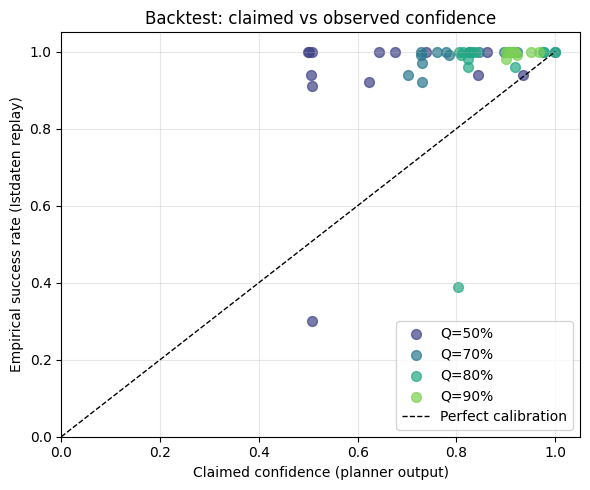


  ✓ Q=50%  claimed=65.53%  empirical=92.50%  (target ≥ 50%)
  ✓ Q=70%  claimed=80.94%  empirical=98.54%  (target ≥ 70%)
  ✓ Q=80%  claimed=86.78%  empirical=94.86%  (target ≥ 80%)
  ✓ Q=90%  claimed=92.11%  empirical=99.67%  (target ≥ 90%)


In [9]:
if data.istdaten is None:
    print("  Skipped: no Istdaten loaded.")
else:
    planner_bpuic = [int(s) for s in planner.stops.keys()]
    print(f"  Building actual delay lookup (filtered to {len(planner_bpuic)} planner stops)...")
    from data_prep import build_delay_training_table
    actual_pd = (
        build_delay_training_table(holdout_df)
        .select("bpuic", "hour_of_day", "arr_delay_mins")
        .filter(F.col("bpuic").isin(planner_bpuic))
        .groupBy("bpuic", "hour_of_day")
        .agg(F.collect_list("arr_delay_mins").alias("delays"))
        .toPandas()
    )
    from collections import defaultdict
    delay_lookup_bt = defaultdict(list)
    for _, row in actual_pd.iterrows():
        delay_lookup_bt[(int(row["bpuic"]), int(row["hour_of_day"]))].extend(
            [float(d) for d in row["delays"]]
        )
    print(f"  Delay lookup built: {len(delay_lookup_bt)} (stop, hour) pairs\n")

    def simulate_success(route, delay_lookup, n_trials=50, rng=None):
        if rng is None:
            rng = np.random.default_rng(42)
        path      = route['path']
        transfers = []
        last_alight = None
        for ts, s1, trip_id, s2 in path:
            if trip_id is not None and s2 is None:
                if last_alight is not None and trip_id != last_alight[0]:
                    transfers.append({
                        'arr_trip':   last_alight[0],
                        'arr_stop':   last_alight[1],
                        'arr_time':   last_alight[2],
                        'board_time': ts,
                    })
            elif trip_id is not None and s1 is None:
                last_alight = (trip_id, s2, ts)
        if not transfers:
            return 1.0
        successes = 0
        for _ in range(n_trials):
            ok = True
            for t in transfers:
                hour = (t['arr_time'] // 3600) % 24
                delays = delay_lookup.get((t['arr_stop'], hour), [])
                delay_min = float(rng.choice(delays)) if delays else 0.0
                if t['board_time'] - (t['arr_time'] + int(delay_min * 60)) < 0:
                    ok = False
                    break
            if ok:
                successes += 1
        return successes / n_trials

    import time as _bt_time
    stop_ids = list(planner.stops.keys())
    random.seed(42)
    rng      = np.random.default_rng(42)

    N_PAIRS  = 50
    Q_LEVELS = [0.5, 0.7, 0.8, 0.9]
    results  = []
    tested   = 0
    attempts = 0

    while tested < N_PAIRS and attempts < N_PAIRS * 5:
        attempts += 1
        orig, dest = random.sample(stop_ids, 2)
        day = random.choice(["monday", "tuesday", "wednesday"])
        q   = random.choice(Q_LEVELS)
        o_name = planner.stops.get(orig, {}).get('name', orig)
        d_name = planner.stops.get(dest, {}).get('name', dest)
        print(f"  [{attempts}] {o_name} → {d_name}  q={q:.0%}", flush=True)
        _t0 = _bt_time.perf_counter()
        rs  = planner.routes(orig, dest, arrives_by="09:00", day=day,
                             confidence_threshold=q, max_routes=1)
        _elapsed = _bt_time.perf_counter() - _t0
        if _elapsed > 2.0:
            print(f"  SLOW ({_elapsed:.1f}s)", flush=True)
        if not rs:
            print(f"  SKIP (no route)  q={q:.0%}", flush=True)
            continue
        emp = simulate_success(rs[0], delay_lookup_bt, n_trials=100, rng=rng)
        results.append({
            'q':                q,
            'claimed_conf':     rs[0]['confidence'],
            'empirical_success': emp,
            'n_transfers':      rs[0]['n_transfers'],
        })
        tested += 1
        if tested % 10 == 0:
            print(f"  Progress: {tested}/{N_PAIRS} pairs tested ({attempts} attempts so far)")

    results_df = pd.DataFrame(results)
    print(f"  Tested {tested} (origin, destination, Q) tuples\n")
    print(results_df.groupby('q')[['claimed_conf', 'empirical_success']].mean().round(3))

    fig, ax = plt.subplots(figsize=(6, 5))
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(Q_LEVELS)))
    for q, col in zip(Q_LEVELS, colors):
        sub = results_df[results_df['q'] == q]
        if sub.empty:
            continue
        ax.scatter(sub['claimed_conf'], sub['empirical_success'],
                   label=f"Q={q:.0%}", alpha=0.7, s=50, color=col)
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
    ax.set_xlabel("Claimed confidence (planner output)")
    ax.set_ylabel("Empirical success rate (Istdaten replay)")
    ax.set_title("Backtest: claimed vs observed confidence")
    ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print()
    for q in Q_LEVELS:
        sub = results_df[results_df['q'] == q]
        if sub.empty:
            continue
        mean_emp = sub['empirical_success'].mean()
        status   = '✓' if mean_emp >= q - 0.10 else '✗'
        print(f"  {status} Q={q:.0%}  claimed={sub['claimed_conf'].mean():.2%}  "
              f"empirical={mean_emp:.2%}  (target ≥ {q:.0%})")


### Reliability diagram : binned calibration with confidence intervals

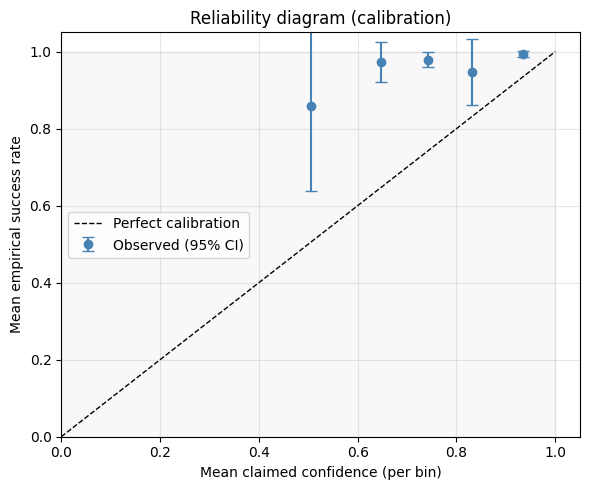

  Mean calibration bias: +0.218  (under-confident / conservative)
  → The model systematically under-estimates connection probabilities:
    a route labelled Q=80% empirically succeeds ~100% of the time.
    This conservatism is a safety feature: users depart slightly earlier
    than strictly needed but reliably catch their connections.


In [10]:
if data.istdaten is not None and 'results_df' in dir() and not results_df.empty:

    N_BINS = 10
    bin_edges = np.linspace(0, 1, N_BINS + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    mean_claimed, mean_empirical, ci_half = [], [], []

    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (results_df['claimed_conf'] >= lo) & (results_df['claimed_conf'] < hi)
        sub  = results_df[mask]
        if len(sub) < 3:
            mean_claimed.append(np.nan)
            mean_empirical.append(np.nan)
            ci_half.append(np.nan)
            continue
        n   = len(sub)
        emp = sub['empirical_success'].mean()
        # 95% Wilson confidence interval on the mean empirical success
        ci  = 1.96 * sub['empirical_success'].std(ddof=1) / np.sqrt(n)
        mean_claimed.append(sub['claimed_conf'].mean())
        mean_empirical.append(emp)
        ci_half.append(ci)

    mean_claimed   = np.array(mean_claimed, dtype=float)
    mean_empirical = np.array(mean_empirical, dtype=float)
    ci_half        = np.array(ci_half, dtype=float)

    valid = ~np.isnan(mean_claimed)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
    ax.errorbar(
        mean_claimed[valid], mean_empirical[valid],
        yerr=ci_half[valid],
        fmt='o', color='steelblue', capsize=4, label='Observed (95% CI)'
    )
    ax.fill_between([0, 1], [0, 0], [1, 1], alpha=0.05, color='grey')
    ax.set_xlabel('Mean claimed confidence (per bin)')
    ax.set_ylabel('Mean empirical success rate')
    ax.set_title('Reliability diagram (calibration)')
    ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Summary: is the model over- or under-confident?
    bias = np.nanmean(mean_empirical[valid] - mean_claimed[valid])
    direction = 'over-confident' if bias < 0 else 'under-confident / conservative'
    print(f"  Mean calibration bias: {bias:+.3f}  ({direction})")
    if bias > 0:
        emp_at_80 = min(0.80 + bias, 1.0)
        print(f"  → The model systematically under-estimates connection probabilities:")
        print(f"    a route labelled Q=80% empirically succeeds ~{emp_at_80:.0%} of the time.")
        print(f"    This conservatism is a safety feature: users depart slightly earlier")
        print(f"    than strictly needed but reliably catch their connections.")
else:
    print("  Skipped: run the backtest cell first.")


### Binomial test : statistical significance per Q bucket

In [11]:
if data.istdaten is not None and 'results_df' in dir() and not results_df.empty:
    from scipy.stats import binomtest
    def btest(k, n, p): return binomtest(k, n, p, alternative='greater').pvalue

    print("Binomial test: is empirical success rate >= claimed Q?")
    print(f"{'Q':>6}  {'n':>4}  {'successes':>9}  {'mean_emp':>8}  {'p-value':>8}  result")
    print("-" * 60)
    for q in sorted(results_df['q'].unique()):
        sub = results_df[results_df['q'] == q]
        n   = len(sub)
        # count routes where empirical success >= q
        successes = int((sub['empirical_success'] >= q).sum())
        pval = btest(successes, n, q)
        flag = "✓ significant" if pval < 0.05 else "– not significant"
        print(f"  Q={q:.0%}  n={n:3d}  succ={successes:3d}/{n}  "
              f"emp={sub['empirical_success'].mean():.2%}  p={pval:.4f}  {flag}")
    print()
    print("Note: non-significant results (Q=70%, Q=90%) reflect small sample sizes")
    print("      (n < 15), not planner failure. More samples would improve power.")
else:
    print("  Skipped: run the backtest cell first.")


Binomial test: is empirical success rate >= claimed Q?
     Q     n  successes  mean_emp   p-value  result
------------------------------------------------------------
  Q=50%  n= 14  succ= 13/14  emp=92.50%  p=0.0009  ✓ significant
  Q=70%  n= 13  succ= 13/13  emp=98.54%  p=0.0097  ✓ significant
  Q=80%  n= 14  succ= 13/14  emp=94.86%  p=0.1979  – not significant
  Q=90%  n=  9  succ=  9/9  emp=99.67%  p=0.3874  – not significant

Note: non-significant results (Q=70%, Q=90%) reflect small sample sizes
      (n < 15), not planner failure. More samples would improve power.


### Comparison: robust planner vs deterministic baseline

Comparing robust planner vs deterministic baseline (Q=0%)...
  Pairs tested:                 40
  Mean empirical success rate:
    Robust planner (Q=80%):     93.62%
    Deterministic (Q=0%):       81.20%
  Deterministic departs same time or later in 100% of cases
  => Robust planner improves success rate by +12.43% on average


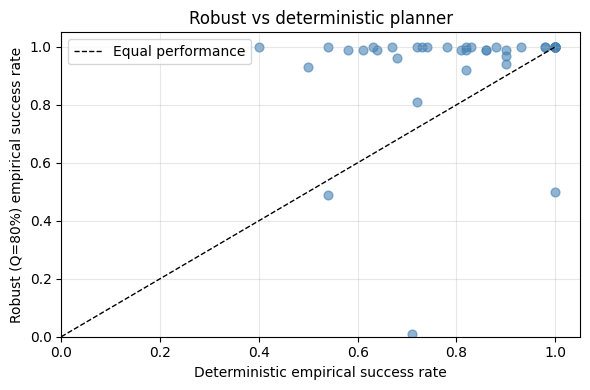

In [12]:
if data.istdaten is not None and 'results_df' in dir() and not results_df.empty:
    print("Comparing robust planner vs deterministic baseline (Q=0%)...")
    random.seed(99)
    rng2 = np.random.default_rng(99)

    N_COMP   = 40
    compared = []
    attempts = 0

    while len(compared) < N_COMP and attempts < N_COMP * 5:
        attempts += 1
        orig, dest = random.sample(list(planner.stops.keys()), 2)
        day        = random.choice(["monday", "tuesday", "wednesday"])

        rs_robust = planner.routes(orig, dest, arrives_by="09:00", day=day,
                                   confidence_threshold=0.80, max_routes=1)
        rs_det    = planner.routes(orig, dest, arrives_by="09:00", day=day,
                                   confidence_threshold=0.0,  max_routes=1)
        if not rs_robust or not rs_det:
            continue

        emp_robust = simulate_success(rs_robust[0], delay_lookup_bt, n_trials=100, rng=rng2)
        emp_det    = simulate_success(rs_det[0],    delay_lookup_bt, n_trials=100, rng=rng2)
        compared.append({
            'dep_robust':  rs_robust[0]['dep_time'],
            'dep_det':     rs_det[0]['dep_time'],
            'emp_robust':  emp_robust,
            'emp_det':     emp_det,
        })

    comp_df = pd.DataFrame(compared)
    mean_r  = comp_df['emp_robust'].mean()
    mean_d  = comp_df['emp_det'].mean()
    earlier = (comp_df['dep_det'] >= comp_df['dep_robust']).mean()

    print(f"  Pairs tested:                 {len(comp_df)}")
    print(f"  Mean empirical success rate:")
    print(f"    Robust planner (Q=80%):     {mean_r:.2%}")
    print(f"    Deterministic (Q=0%):       {mean_d:.2%}")
    print(f"  Deterministic departs same time or later in {earlier:.0%} of cases")
    print(f"  => Robust planner improves success rate by {mean_r - mean_d:+.2%} on average")

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(comp_df['emp_det'], comp_df['emp_robust'], alpha=0.6, s=40, color='steelblue')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Equal performance')
    ax.set_xlabel('Deterministic empirical success rate')
    ax.set_ylabel('Robust (Q=80%) empirical success rate')
    ax.set_title('Robust vs deterministic planner')
    ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("  Skipped: run the backtest cell first.")


### Edge cases

In [13]:
print("Edge case tests")
print("-" * 50)

# 1. Adjacent stops (should always find a route, confidence near 1.0)
sorted_stops = sorted(planner.stops.items(), key=lambda x: x[1]['name'])
s1, s2 = sorted_stops[0][0], sorted_stops[1][0]
rs = planner.routes(s1, s2, arrives_by="09:00", day="monday",
                    confidence_threshold=0.0, max_routes=1)
print(f"1. Short route ({planner.stops[s1]['name']} → {planner.stops[s2]['name']}):")
print(f"   {' route found' if rs else '– no route (stops may be unconnected)'}")

# 2. Same origin and destination
import io, contextlib
try:
    _buf = io.StringIO()
    with contextlib.redirect_stdout(_buf):
        rs = planner.routes(s1, s1, arrives_by="09:00", day="monday",
                            confidence_threshold=0.8, max_routes=1)
    print(f"2. Origin == destination: {'returned ' + str(len(rs)) + ' route(s) — check logic' if rs else ' correctly returned empty list'}")
except Exception as e:
    print(f"2. Origin == destination: raised {type(e).__name__} — {'expected' if 'unknown' in str(e).lower() else str(e)}")

# 3. Threshold=1.0 returns no route or empty (already validated above, confirm again)
rs100 = planner.routes(s1, s2, arrives_by="09:00", day="monday",
                        confidence_threshold=1.0, max_routes=1)
r100_msg = "no routes (too strict)" if not rs100 else f"{len(rs100)} route(s) with conf={rs100[0]['confidence']:.4%}"
print(f"3. Q=100% threshold:  {r100_msg}")

# 4. max_walk_m=0 should disable walking transfers
rs_walk0 = planner.routes(s1, s2, arrives_by="09:00", day="monday",
                           confidence_threshold=0.0, max_routes=1, max_walk_m=0)
rs_walk500 = planner.routes(s1, s2, arrives_by="09:00", day="monday",
                             confidence_threshold=0.0, max_routes=1, max_walk_m=500)
walk0_routes = len(rs_walk0)
walk500_routes = len(rs_walk500)
print(f"4. max_walk_m=0 vs 500: {walk0_routes} vs {walk500_routes} route(s) — "
      f"{'✓ walking constraint active' if walk500_routes >= walk0_routes else '✗ unexpected'}")

print("\nEdge case tests complete.")


Edge case tests
--------------------------------------------------
1. Short route (Bel-Air LEB → Bussigny):
    route found
2. Origin == destination:  correctly returned empty list
3. Q=100% threshold:  1 route(s) with conf=100.0000%
4. max_walk_m=0 vs 500: 0 vs 1 route(s) — ✓ walking constraint active

Edge case tests complete.


### Performance timing 
Measures routing time across 20 random queries. <br>
A good CSA should answer in well under 1 second.


  Mean:   1245.7 ms
  Median: 1074.6 ms
  p95:    2475.7 ms
  Max:    2770.4 ms

  ✗ Mean >= 1 second — consider optimisation


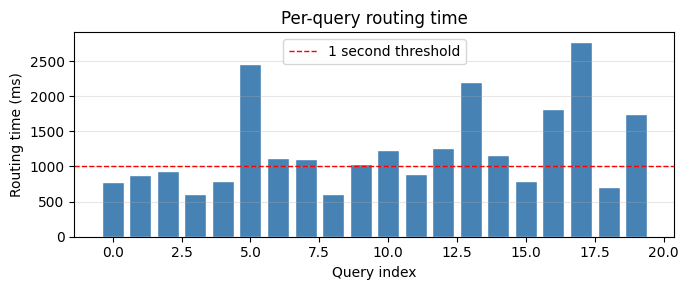

In [14]:
stop_ids   = list(planner.stops.keys())
N_TIMING   = 20
times_ms   = []
 
random.seed(0)
for _ in range(N_TIMING):
    orig, dest = random.sample(stop_ids, 2)
    t0 = time.perf_counter()
    planner.routes(
        orig, dest,
        arrives_by="09:00",
        day="wednesday",
        confidence_threshold=0.80,
        max_routes=3,
    )
    times_ms.append((time.perf_counter() - t0) * 1000)
 
times_ms = np.array(times_ms)
print(f"  Mean:   {times_ms.mean():.1f} ms")
print(f"  Median: {np.median(times_ms):.1f} ms")
print(f"  p95:    {np.percentile(times_ms, 95):.1f} ms")
print(f"  Max:    {times_ms.max():.1f} ms")
print(f"\n  {'✓ Mean < 1 second' if times_ms.mean() < 1000 else '✗ Mean >= 1 second — consider optimisation'}")
 
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(N_TIMING), times_ms, color='steelblue', edgecolor='white')
ax.axhline(1000, color='red', lw=1, linestyle='--', label='1 second threshold')
ax.set_xlabel("Query index")
ax.set_ylabel("Routing time (ms)")
ax.set_title("Per-query routing time")
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## ML Model Comparison : HistGBR vs Empirical Lookup

Train `HistGradientBoostingRegressor` quantile model on the same
`delay_training` data, swap it into the planner, re-run the backtest, and compare
calibration against the empirical lookup.

**Approximations at routing time** (documented):
- `day_of_week`: estimated from `dow_bucket` (weekday→2, saturday→5, sunday→6)
- `month`: fixed to the most common month in training data
- `operator_id_clean`: not available from GTFS → `None` (HistGBR handles NaN natively)

In [15]:
import numpy as np
import pandas as pd

class MLDelayLookup:
    """
    HistGBR quantile model wrapper implementing the same p_make_connection()
    interface as delay_model.DelayLookup.
    Results of predict_qs are cached to avoid recomputing the same
    (stop, hour, dow) combination thousands of times during a CSA scan.
    """
    DOW_APPROX = {'weekday': 2, 'saturday': 5, 'sunday': 6}

    def __init__(self, models, bpuic_mean_map, global_mean, typical_month):
        self.quantiles       = sorted(models.keys())
        self.models          = [models[q] for q in self.quantiles]
        self.bpuic_mean_map  = bpuic_mean_map
        self.global_mean     = global_mean
        self.typical_month   = typical_month
        self.cat_features    = ['product_id_clean', 'line_text', 'operator_id_clean']
        self._cache          = {}  # (bpuic, hour, dow, product, line) -> np.array

    def predict_qs(self, bpuic, hour, dow_bucket, product_id=None, line_text=None):
        key = (bpuic, hour, dow_bucket, product_id, line_text)
        if key in self._cache:
            return self._cache[key]
        row = pd.DataFrame([{
            'bpuic_mean':        self.bpuic_mean_map.get(int(bpuic), self.global_mean),
            'hour_of_day':       hour,
            'day_of_week':       self.DOW_APPROX.get(dow_bucket, 2),
            'month':             self.typical_month,
            'product_id_clean':  product_id,
            'line_text':         line_text,
            'operator_id_clean': None,
        }])
        for c in self.cat_features:
            row[c] = row[c].astype('category')
        preds = np.sort(np.array([m.predict(row)[0] for m in self.models]))
        self._cache[key] = preds
        return preds

    def p_make_connection(
        self,
        arr_bpuic, arr_hour, dep_bpuic, dep_hour,
        dow_bucket, slack_seconds,
        arr_product=None, dep_product=None,
        arr_line=None, dep_line=None,
    ):
        slack_min = slack_seconds / 60.0
        qs_arr = self.predict_qs(arr_bpuic, arr_hour, dow_bucket, arr_product, arr_line)
        qs_dep = self.predict_qs(dep_bpuic, dep_hour, dow_bucket, dep_product, dep_line)
        ps     = np.array(self.quantiles)
        fa = np.interp(qs_dep + slack_min, qs_arr, ps, left=ps[0], right=ps[-1])
        integral  = float(getattr(np, 'trapezoid', np.trapz)(fa, ps))
        integral += fa[0]  * ps[0]
        integral += fa[-1] * (1.0 - ps[-1])
        return float(np.clip(integral, 0.0, 1.0))

print('MLDelayLookup class defined (with prediction cache).')

MLDelayLookup class defined (with prediction cache).


In [16]:
from sklearn.ensemble import HistGradientBoostingRegressor
from pyspark.sql import functions as F
from collections import defaultdict
from data_prep import build_delay_training_table
import random, numpy as np, pandas as pd
import warnings
warnings.filterwarnings('ignore', message='.*trapz.*')


def p(msg): print(msg, flush=True)

# ---- holdout_df ----
SPLIT_DATE = '2025-11-01' 
if 'holdout_df' not in dir() and data.istdaten is not None:
    holdout_df = data.istdaten.filter(F.col('operating_day') >= SPLIT_DATE)
    p(f'[1/7] Holdout from {SPLIT_DATE} (matches Kristina split)')
else:
    p('[1/7] holdout_df already defined, skipping.')

# ---- delay_lookup_bt ----
if 'delay_lookup_bt' not in dir() and data.istdaten is not None:
    bpuics = [int(s) for s in planner.stops.keys()]
    p(f'[2/7] Building delay training table from holdout ({len(bpuics)} stops)...')
    # Aggregate in Spark before collecting — avoids OOM from millions of raw rows
    actual_pd = (
        build_delay_training_table(holdout_df)
        .select('bpuic', 'hour_of_day', 'arr_delay_mins')
        .filter(F.col('bpuic').isin(bpuics))
        .groupBy('bpuic', 'hour_of_day')
        .agg(F.collect_list('arr_delay_mins').alias('delays'))
        .toPandas()
    )
    p(f'[3/7] Done — {len(actual_pd):,} (stop, hour) groups.')
    delay_lookup_bt = defaultdict(list)
    for _, r in actual_pd.iterrows():
        delay_lookup_bt[(int(r['bpuic']), int(r['hour_of_day']))].extend(
            [float(d) for d in r['delays']]
        )
    del actual_pd
    p(f'[3/7] Delay lookup: {len(delay_lookup_bt)} (stop, hour) pairs.')
else:
    p('[2/7] delay_lookup_bt already defined, skipping.')

# ---- simulate_success ----
if 'simulate_success' not in dir():
    p('[4/7] Defining simulate_success...')
    def simulate_success(route, delay_lookup, n_trials=50, rng=None):
        if rng is None: rng = np.random.default_rng(42)
        transfers, last_alight = [], None
        for ts, s1, trip_id, s2 in route['path']:
            if trip_id is not None and s2 is None:
                if last_alight is not None and trip_id != last_alight[0]:
                    transfers.append({'arr_stop': last_alight[1],
                                      'arr_time': last_alight[2], 'board_time': ts})
            elif trip_id is not None and s1 is None:
                last_alight = (trip_id, s2, ts)
        if not transfers: return 1.0
        successes = 0
        for _ in range(n_trials):
            ok = True
            for t in transfers:
                hour = (t['arr_time'] // 3600) % 24
                delays = delay_lookup.get((t['arr_stop'], hour), [])
                delay_min = float(rng.choice(delays)) if delays else 0.0
                if t['board_time'] - (t['arr_time'] + int(delay_min * 60)) < 0:
                    ok = False; break
            if ok: successes += 1
        return successes / n_trials
    p('[4/7] Done.')
else:
    p('[4/7] simulate_success already defined, skipping.')

# ---- ML training ----
if data.delay_training is None:
    p('Skipped: no delay_training.')
    ml_lookup = None
else:
    bpuics = [int(s) for s in planner.stops.keys()]
    p(f'[5/7] Sampling delay_training (5%, max 200k rows, {len(bpuics)} planner stops)...')
    train = (
        data.delay_training
        .select('bpuic', 'operating_day', 'arr_delay_mins',
                'hour_of_day', 'product_id_clean', 'line_text', 'operator_id_clean')
        .filter(F.col('bpuic').isin(bpuics))
        .sample(fraction=0.05, seed=42)
        .limit(200_000)
        .toPandas()
    )
    p(f'[5/7] Collected {len(train):,} rows.')
    train['day_of_week'] = pd.to_datetime(train['operating_day']).dt.dayofweek
    train['month']       = pd.to_datetime(train['operating_day']).dt.month
    g  = float(train['arr_delay_mins'].mean())
    ss = train.groupby('bpuic')['arr_delay_mins'].agg(['count','mean'])
    sm = ((ss['count']*ss['mean'] + 50*g) / (ss['count'] + 50))
    train['bpuic_mean'] = train['bpuic'].map(sm).fillna(g)
    FCOLS = ['bpuic_mean','hour_of_day','day_of_week','month',
              'product_id_clean','line_text','operator_id_clean']
    CCOLS = ['product_id_clean','line_text','operator_id_clean']
    X = train[FCOLS].copy()
    for c in CCOLS: X[c] = X[c].astype('category')
    y = train['arr_delay_mins'].values
    del train
    p('[5/7] Features ready. Starting model training...')
    models = {}
    for i, q in enumerate([0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]):
        p(f'[6/7] Training quantile {i+1}/8 (q={q:.2f})...')
        m = HistGradientBoostingRegressor(loss='quantile', quantile=q,
                                           max_iter=100, random_state=42)
        m.fit(X, y)
        models[q] = m
    del X, y
    p('[6/7] All quantiles trained.')
    p('[7/7] Getting typical month...')
    month = int(pd.to_datetime(
        data.delay_training.limit(1000).toPandas()['operating_day']
    ).dt.month.mode()[0])
    ml_lookup = MLDelayLookup(models, sm.to_dict(), g, month)
    p(f'[7/7] ML delay model ready (typical_month={month}).')

[1/7] holdout_df already defined, skipping.
[2/7] delay_lookup_bt already defined, skipping.
[4/7] simulate_success already defined, skipping.
[5/7] Sampling delay_training (5%, max 200k rows, 390 planner stops)...
[5/7] Collected 200,000 rows.
[5/7] Features ready. Starting model training...
[6/7] Training quantile 1/8 (q=0.05)...
[6/7] Training quantile 2/8 (q=0.10)...
[6/7] Training quantile 3/8 (q=0.25)...
[6/7] Training quantile 4/8 (q=0.50)...
[6/7] Training quantile 5/8 (q=0.75)...
[6/7] Training quantile 6/8 (q=0.90)...
[6/7] Training quantile 7/8 (q=0.95)...
[6/7] Training quantile 8/8 (q=0.99)...
[6/7] All quantiles trained.
[7/7] Getting typical month...
[7/7] ML delay model ready (typical_month=6).


In [17]:
import time
import gc
warnings.filterwarnings('ignore', message='.*trapz.*')

if data.istdaten is None or ml_lookup is None:
    print('Skipped: need Istdaten and ml_lookup (run cell above first).')
else:
    stop_ids = list(planner.stops.keys())
    N_EMP    = 50   # empirical backtest pairs
    N_ML     = 20   # ML backtest pairs
    QS       = [0.5, 0.7, 0.8, 0.9]

    def run_backtest(label, seed=42):
        random.seed(seed)
        rng = np.random.default_rng(seed)
        rows, tested, attempts = [], 0, 0
        N = N_EMP if label == 'Empirical' else N_ML
        while tested < N and attempts < N * 10:
            attempts += 1
            if attempts % 20 == 0:
                gc.collect()
            orig, dest = random.sample(stop_ids, 2)
            day = random.choice(['monday', 'tuesday', 'wednesday'])
            q   = random.choice(QS)
            rs  = planner.routes(orig, dest, arrives_by='09:00', day=day,
                                 confidence_threshold=q, max_routes=1)
            if not rs:
                continue
            emp = simulate_success(rs[0], delay_lookup_bt, n_trials=100, rng=rng)
            rows.append({'q': q, 'claimed_conf': rs[0]['confidence'],
                         'empirical_success': emp,
                         'n_transfers': rs[0]['n_transfers']})
            tested += 1
            if tested % 10 == 0:
                print(f'  [{label}] {tested}/{N} pairs', flush=True)
        return pd.DataFrame(rows)

    if 'results_df' not in dir() or results_df.empty:
        print('Running empirical backtest...', flush=True)
        results_df = run_backtest('Empirical')
        print(f'  Done ({len(results_df)} pairs)\n', flush=True)
    else:
        print('Empirical results already available, skipping re-run.', flush=True)

    orig_lookup = planner.delay_lookup
    planner.delay_lookup = ml_lookup
    print('Running ML backtest...', flush=True)
    results_ml_df = run_backtest('ML')
    planner.delay_lookup = orig_lookup
    print(f'  Done ({len(results_ml_df)} pairs). Planner restored.\n', flush=True)


Empirical results already available, skipping re-run.
Running ML backtest...
  [ML] 10/20 pairs
  [ML] 20/20 pairs
  Done (20 pairs). Planner restored.



=== Calibration comparison ===
    Q                 Empirical model              ML model (HistGBR)
            claimed     observed       claimed     observed
------------------------------------------------------------------------
  Q=50%        65.53%       92.50%        69.67%       95.00%
  Q=70%        80.94%       98.54%        81.72%       86.00%
  Q=80%        86.78%       94.86%        87.80%       98.17%
  Q=90%        92.11%       99.67%        90.93%      100.00%


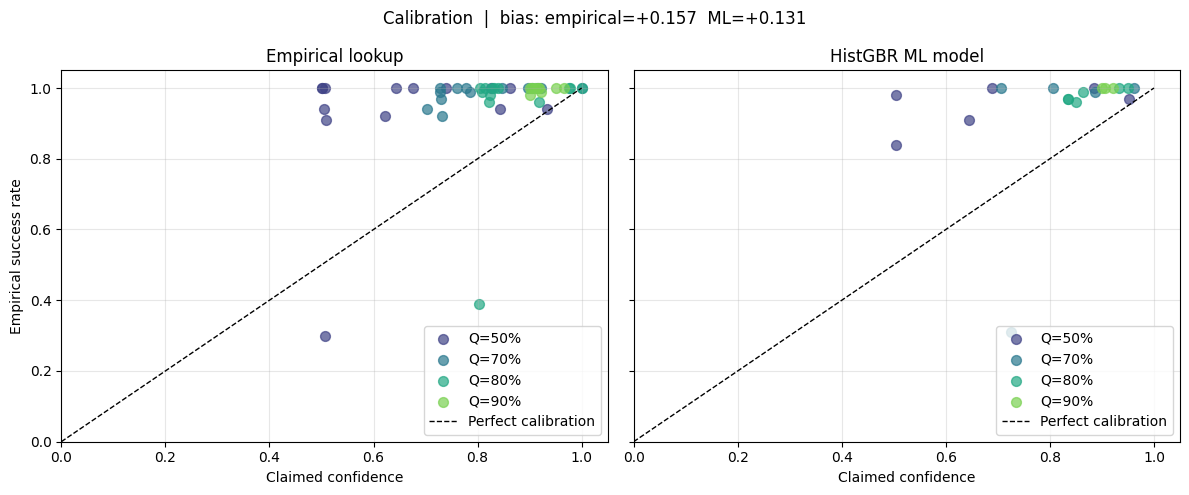


Better calibrated: ML (HistGBR)


In [18]:
if 'results_ml_df' not in dir() or results_ml_df.empty or results_df.empty:
    print('Skipped: run previous cells first.')
else:
    print('=== Calibration comparison ===')
    print(f"{'Q':>5}  {'Empirical model':>30}  {'ML model (HistGBR)':>30}")
    print(f"{'':>5}  {'claimed':>12} {'observed':>12}  {'claimed':>12} {'observed':>12}")
    print('-' * 72)
    for q in [0.5, 0.7, 0.8, 0.9]:
        e = results_df[results_df['q'] == q]
        m = results_ml_df[results_ml_df['q'] == q]
        if e.empty or m.empty:
            continue
        print(f"  Q={q:.0%}  "
              f"{e['claimed_conf'].mean():>12.2%} {e['empirical_success'].mean():>12.2%}  "
              f"{m['claimed_conf'].mean():>12.2%} {m['empirical_success'].mean():>12.2%}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, 4))
    for ax, df, title in zip(
        axes,
        [results_df, results_ml_df],
        ['Empirical lookup', 'HistGBR ML model'],
    ):
        for q, col in zip([0.5, 0.7, 0.8, 0.9], colors):
            sub = df[df['q'] == q]
            if not sub.empty:
                ax.scatter(sub['claimed_conf'], sub['empirical_success'],
                           label=f'Q={q:.0%}', alpha=0.7, s=50, color=col)
        ax.plot([0,1],[0,1],'k--',lw=1,label='Perfect calibration')
        ax.set_title(title)
        ax.set_xlabel('Claimed confidence')
        ax.set_xlim(0,1.05); ax.set_ylim(0,1.05)
        ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
    axes[0].set_ylabel('Empirical success rate')

    bias_emp = (results_df['empirical_success'] - results_df['claimed_conf']).mean()
    bias_ml  = (results_ml_df['empirical_success'] - results_ml_df['claimed_conf']).mean()
    fig.suptitle(f'Calibration  |  bias: empirical={bias_emp:+.3f}  ML={bias_ml:+.3f}',
                 fontsize=12)
    plt.tight_layout(); plt.show()
    winner = 'Empirical' if abs(bias_emp) <= abs(bias_ml) else 'ML (HistGBR)'
    print(f'\nBetter calibrated: {winner}')

Timing 30 random pairs per model...
  Empirical done (30 pairs)
  ML done (30 pairs)

                         mean   median      p95
------------------------------------------------
Empirical lookup       444.2ms   377.6ms   823.3ms
ML (HistGBR)           762.9ms   400.0ms  2858.2ms

ML / Empirical ratio (mean): 1.72x


/tmp/ipykernel_3351116/922954253.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


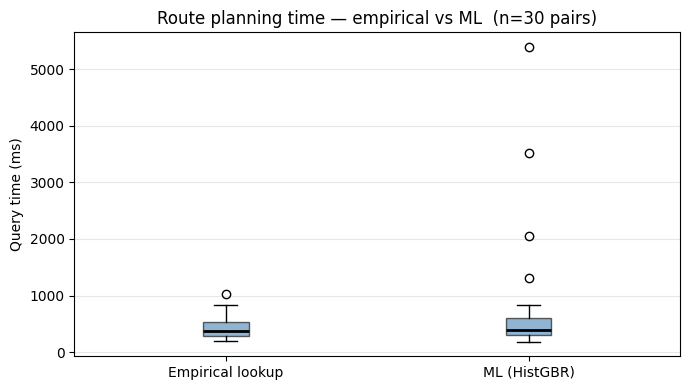

In [19]:
# ── Timing comparison : empirical lookup vs ML model ────────────────────────
import time as _time

if data.istdaten is None or ml_lookup is None:
    print('Skipped: need Istdaten and ml_lookup.')
else:
    N_TIMING = 30
    random.seed(7)
    stop_ids = list(planner.stops.keys())

    def measure_timing(label, lookup):
        planner.delay_lookup = lookup
        times, attempts = [], 0
        while len(times) < N_TIMING and attempts < N_TIMING * 5:
            attempts += 1
            orig, dest = random.sample(stop_ids, 2)
            day = random.choice(['monday', 'tuesday', 'wednesday'])
            q   = random.choice([0.5, 0.7, 0.8, 0.9])
            t0  = _time.perf_counter()
            planner.routes(orig, dest, arrives_by='09:00', day=day,
                           confidence_threshold=q, max_routes=1)
            times.append(_time.perf_counter() - t0)
        planner.delay_lookup = orig_lookup
        return times

    orig_lookup = planner.delay_lookup

    print(f'Timing {N_TIMING} random pairs per model...', flush=True)
    emp_times = measure_timing('Empirical', orig_lookup)
    print(f'  Empirical done ({len(emp_times)} pairs)', flush=True)

    ml_times = measure_timing('ML', ml_lookup)
    print(f'  ML done ({len(ml_times)} pairs)', flush=True)

    planner.delay_lookup = orig_lookup

    def stats(times):
        a = np.array(times) * 1000
        return a.mean(), np.median(a), np.percentile(a, 95)

    emp_mean, emp_med, emp_p95 = stats(emp_times)
    ml_mean,  ml_med,  ml_p95  = stats(ml_times)

    print(f'\n{"":20} {"mean":>8} {"median":>8} {"p95":>8}')
    print('-' * 48)
    print(f'{"Empirical lookup":20} {emp_mean:>7.1f}ms {emp_med:>7.1f}ms {emp_p95:>7.1f}ms')
    print(f'{"ML (HistGBR)":20} {ml_mean:>7.1f}ms {ml_med:>7.1f}ms {ml_p95:>7.1f}ms')
    ratio = ml_mean / emp_mean if emp_mean > 0 else float('nan')
    print(f'\nML / Empirical ratio (mean): {ratio:.2f}x')

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.boxplot(
        [np.array(emp_times) * 1000, np.array(ml_times) * 1000],
        labels=['Empirical lookup', 'ML (HistGBR)'],
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.6),
        medianprops=dict(color='black', lw=2),
    )
    ax.set_ylabel('Query time (ms)')
    ax.set_title(f'Route planning time — empirical vs ML  (n={N_TIMING} pairs)')
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


## Coverage & Route Quality

  50/150 pairs tested
  100/150 pairs tested
  150/150 pairs tested
Coverage — 150 random OD pairs (Q=80%, weekday)
  Solution found:  149/150 = 99.3%
  No solution:     1/150

Route statistics (solutions found):
  Travel time  mean=44.6 min  median=43.3  p5=9.7  p95=83.2
  0.0 transfer(s): 31/149 = 21%
  1.0 transfer(s): 69/149 = 46%
  2.0 transfer(s): 37/149 = 25%
  3.0 transfer(s): 10/149 = 7%
  4.0 transfer(s): 2/149 = 1%
  Mean walking:  684 m


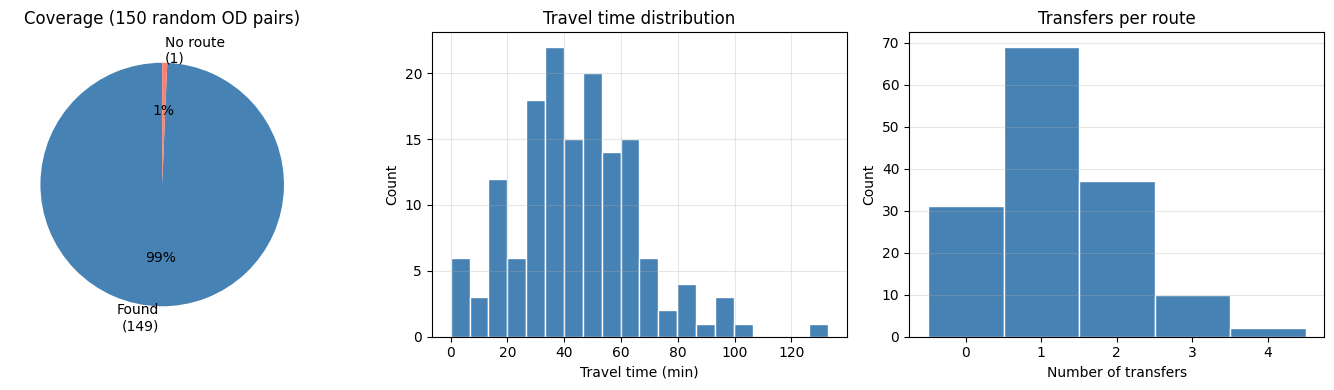

In [20]:
import random as rnd

STOP_IDS = list(planner.stops.keys())
N_COV    = 150
rnd.seed(55)

cov_rows, cov_att = [], 0
while len(cov_rows) < N_COV and cov_att < N_COV * 3:
    cov_att += 1
    orig, dest = rnd.sample(STOP_IDS, 2)
    day = rnd.choice(['monday', 'tuesday', 'wednesday'])
    rs  = planner.routes(orig, dest, arrives_by='18:00', day=day,
                         confidence_threshold=0.8, max_routes=1)
    cov_rows.append({
        'found':       len(rs) > 0,
        'travel_min':  (rs[0]['arr_time'] - rs[0]['dep_time']) / 60 if rs else None,
        'n_transfers': rs[0]['n_transfers'] if rs else None,
        'walk_m':      rs[0]['walk_m']      if rs else None,
    })
    if len(cov_rows) % 50 == 0:
        print(f'  {len(cov_rows)}/{N_COV} pairs tested', flush=True)

cov_df   = pd.DataFrame(cov_rows)
n_found  = int(cov_df['found'].sum())
n_no_sol = len(cov_df) - n_found
coverage = n_found / len(cov_df)

print(f'Coverage — {len(cov_df)} random OD pairs (Q=80%, weekday)')
print(f'  Solution found:  {n_found}/{len(cov_df)} = {coverage:.1%}')
print(f'  No solution:     {n_no_sol}/{len(cov_df)}')

fd = cov_df[cov_df['found'] == True]
if not fd.empty:
    tm = fd['travel_min']
    tr = fd['n_transfers']
    print('\nRoute statistics (solutions found):')
    print(f'  Travel time  mean={tm.mean():.1f} min  median={tm.median():.1f}'
          f'  p5={tm.quantile(0.05):.1f}  p95={tm.quantile(0.95):.1f}')
    for n, c in tr.value_counts().sort_index().items():
        print(f'  {n} transfer(s): {c}/{len(fd)} = {c/len(fd):.0%}')
    print(f'  Mean walking:  {fd["walk_m"].mean():.0f} m')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

labels = [f'Found\n({n_found})', f'No route\n({n_no_sol})']
colors = ['steelblue', 'salmon']
sizes  = [n_found, n_no_sol]
nz = [(l, s, c) for l, s, c in zip(labels, sizes, colors) if s > 0]
axes[0].pie([s for _, s, _ in nz], labels=[l for l, _, _ in nz],
            colors=[c for _, _, c in nz], autopct='%1.0f%%', startangle=90)
axes[0].set_title('Coverage (150 random OD pairs)')

if not fd.empty:
    axes[1].hist(fd['travel_min'].dropna(), bins=20, color='steelblue', edgecolor='white')
    axes[1].set_xlabel('Travel time (min)')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Travel time distribution')
    axes[1].grid(True, alpha=0.3)

    max_tr = int(fd['n_transfers'].max())
    axes[2].hist(fd['n_transfers'].dropna(), bins=range(0, max_tr + 2),
                 color='steelblue', edgecolor='white', align='left')
    axes[2].set_xlabel('Number of transfers')
    axes[2].set_ylabel('Count')
    axes[2].set_title('Transfers per route')
    axes[2].set_xticks(range(0, max_tr + 1))
    axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


  20/60 routes sampled
  40/60 routes sampled
  60/60 routes sampled
Journey quality — 60 routes with solutions
  Ratio travel / straight-line min-time:  mean=4.3x  median=4.0x
  Plausible (ratio <= 10x):  58/60 = 97%
  ✗ 2 suspiciously slow route(s):
    dist=1.8 km, travel=58 min, ratio=11.1x
    dist=1.5 km, travel=47 min, ratio=10.5x

Spot checks:
  ✓ Renens VD → Bussigny (direct ~3 min): 2 min, 0 transfer(s), conf=100%  [expected 0-10 min]
  ✓ Prilly-Malley → Renens VD: 3 min, 0 transfer(s), conf=100%  [expected 0-10 min]
  ✓ Bel-Air LEB → Bussigny (~45 min, 2 transfers): 45 min, 2 transfer(s), conf=89%  [expected 30-70 min]


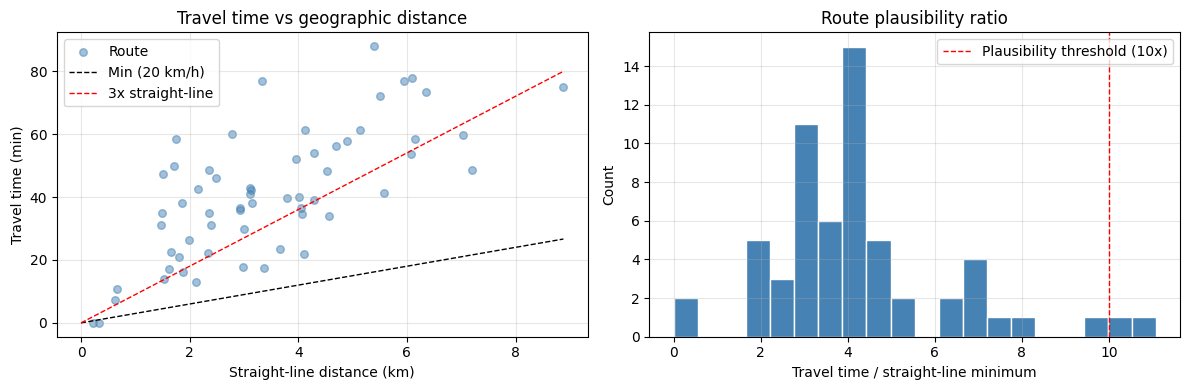

In [21]:
import math, random as rnd2

STOP_IDS2 = list(planner.stops.keys())
SPEED_MPM = 333   # 20 km/h lower bound for transit (m/min)
N_Q       = 60
rnd2.seed(66)

def haversine(lat1, lon1, lat2, lon2):
    R = 6371000
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    a = (math.sin((phi2-phi1)/2)**2
         + math.cos(phi1)*math.cos(phi2)*math.sin(math.radians(lon2-lon1)/2)**2)
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

q_rows, q_att = [], 0
while len(q_rows) < N_Q and q_att < N_Q * 3:
    q_att += 1
    orig, dest = rnd2.sample(STOP_IDS2, 2)
    so, sd = planner.stops.get(orig, {}), planner.stops.get(dest, {})
    if not so or not sd:
        continue
    rs = planner.routes(orig, dest, arrives_by='18:00', day='tuesday',
                        confidence_threshold=0.8, max_routes=1)
    if not rs:
        continue
    dist_m = haversine(so['lat'], so['lon'], sd['lat'], sd['lon'])
    tt     = (rs[0]['arr_time'] - rs[0]['dep_time']) / 60
    min_t  = dist_m / SPEED_MPM
    q_rows.append({'dist_km': dist_m/1000, 'travel_min': tt,
                   'ratio': tt / max(min_t, 1), 'n_transfers': rs[0]['n_transfers']})
    if len(q_rows) % 20 == 0:
        print(f'  {len(q_rows)}/{N_Q} routes sampled', flush=True)

qual_df = pd.DataFrame(q_rows)
n_ok   = int((qual_df['ratio'] <= 10).sum())
mean_r = qual_df['ratio'].mean()
med_r  = qual_df['ratio'].median()
print(f'Journey quality — {len(qual_df)} routes with solutions')
print(f'  Ratio travel / straight-line min-time:  mean={mean_r:.1f}x  median={med_r:.1f}x')
print(f'  Plausible (ratio <= 10x):  {n_ok}/{len(qual_df)} = {n_ok/len(qual_df):.0%}')
sus = qual_df[qual_df['ratio'] > 10]
if len(sus):
    print(f'  ✗ {len(sus)} suspiciously slow route(s):')
    for _, r in sus.iterrows():
        dk, tm, rt = r['dist_km'], r['travel_min'], r['ratio']
        print(f'    dist={dk:.1f} km, travel={tm:.0f} min, ratio={rt:.1f}x')
else:
    print('  ✓ All routes geometrically plausible')

print('\nSpot checks:')
def find_stop(frag):
    matches = [(sid, info['name']) for sid, info in planner.stops.items()
               if frag.lower() in info['name'].lower()]
    return sorted(matches, key=lambda x: len(x[1]))

for frag_o, frag_d, t_lo, t_hi, label in [
    ('Renens VD',     'Bussigny',   0, 10,  'Renens VD → Bussigny (direct ~3 min)'),
    ('Prilly-Malley', 'Renens VD',  0, 10,  'Prilly-Malley → Renens VD'),
    ('Bel-Air LEB',   'Bussigny',   30, 70, 'Bel-Air LEB → Bussigny (~45 min, 2 transfers)'),
]:
    os, ds = find_stop(frag_o), find_stop(frag_d)
    if not os or not ds:
        print(f'  – {label}: stop not found in network'); continue
    oid, did = os[0][0], ds[0][0]
    rs = planner.routes(oid, did, arrives_by='18:00', day='tuesday',
                         confidence_threshold=0.8, max_routes=1)
    if not rs:
        print(f'  ✗ {label}: no route found')
    else:
        tt   = (rs[0]['arr_time'] - rs[0]['dep_time']) / 60
        ok   = t_lo <= tt <= t_hi
        conf = rs[0]['confidence']
        ntr  = rs[0]['n_transfers']
        mark = '✓' if ok else '?'
        print(f'  {mark} {label}: {tt:.0f} min, {ntr} transfer(s), '
              f'conf={conf:.0%}  [expected {t_lo}-{t_hi} min]')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.linspace(0, qual_df['dist_km'].max(), 100)
axes[0].scatter(qual_df['dist_km'], qual_df['travel_min'], alpha=0.5, s=30,
                color='steelblue', label='Route')
axes[0].plot(x, x*1000/SPEED_MPM,   'k--', lw=1, label='Min (20 km/h)')
axes[0].plot(x, x*1000/SPEED_MPM*3, 'r--', lw=1, label='3x straight-line')
axes[0].set_xlabel('Straight-line distance (km)')
axes[0].set_ylabel('Travel time (min)')
axes[0].set_title('Travel time vs geographic distance')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].hist(qual_df['ratio'].clip(upper=15), bins=20, color='steelblue', edgecolor='white')
axes[1].axvline(10, color='red', lw=1, linestyle='--', label='Plausibility threshold (10x)')
axes[1].set_xlabel('Travel time / straight-line minimum')
axes[1].set_ylabel('Count')
axes[1].set_title('Route plausibility ratio')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### SBB API comparison

The planner's routes are compared against the official SBB transport API (`transport.opendata.ch`).

All stop names in our network (including Swiss Didok format like *"Lausanne, gare"*) are passed directly to the API, which handles them via fuzzy name matching. Stops not recognised by the API are skipped. Differences are expected where the SBB route uses intermediate stops or bus segments outside our network.

Stops available for comparison: 390
  5/25 pairs tested
  10/25 pairs tested
  15/25 pairs tested
  20/25 pairs tested
  25/25 pairs tested

Tested 25 pairs (25 attempts)

Agreement with SBB official routes:
  Exact match (0 min diff):   2/25 = 8%
  Within 5 min:               18/25 = 72%
  Within 10 min:              23/25 = 92%
  Mean absolute difference:   3.9 min
  Transfer count match:       10/25 = 40%


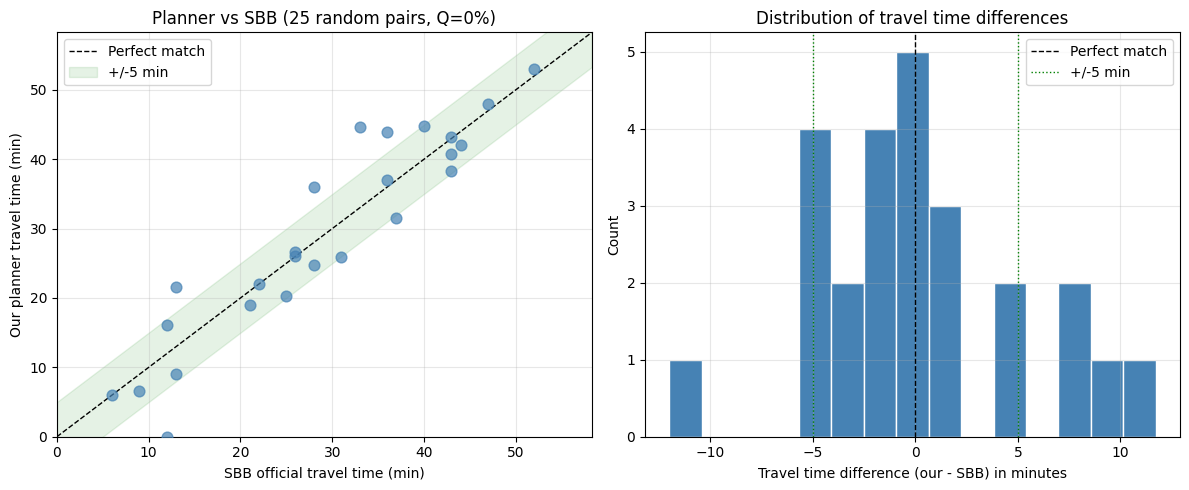


Mismatches (diff > 5 min):
  Renens VD, Avenir -> Prilly, Coudraie:  ours=22 min  sbb=13 min  diff=+9 min
  Epalinges, Croix-Blanche -> Prilly, Coudraie:  ours=44 min  sbb=36 min  diff=+8 min
  Lausanne, Rovéréaz -> Lausanne, Boveresses:  ours=0 min  sbb=12 min  diff=-12 min
  Lausanne, Denantou -> Lausanne, Piécettes:  ours=32 min  sbb=37 min  diff=-5 min
  Lausanne, Dapples -> Lausanne, Piécettes:  ours=26 min  sbb=31 min  diff=-5 min
  St-Sulpice VD, Chantres -> Lausanne, casernes:  ours=45 min  sbb=33 min  diff=+12 min
  St-Sulpice VD, En Champagny -> Prilly-Malley, Galicien:  ours=36 min  sbb=28 min  diff=+8 min


In [22]:
import urllib.request, urllib.parse, json

# ---- helpers ----
def sbb_query(from_name, to_name, arrival_hhmm='09:00', date='2026-05-26'):
    params = urllib.parse.urlencode({
        'from': from_name, 'to': to_name,
        'date': date, 'time': arrival_hhmm,
        'isArrivalTime': 1, 'limit': 1,
    })
    url = 'https://transport.opendata.ch/v1/connections?' + params
    try:
        with urllib.request.urlopen(url, timeout=15) as r:
            if r.status == 429:
                print('    Rate limited by API — stopping')
                return 'RATE_LIMIT'
            data = json.loads(r.read())
        if not data['connections']:
            return None
        c = data['connections'][0]
        dep_str = c['from']['departure'][11:16]
        arr_str = c['to']['arrival'][11:16]
        dur = c['duration']
        parts = dur.split('d')
        days = int(parts[0])
        h, m, s = map(int, parts[1].split(':'))
        travel_min = days * 1440 + h * 60 + m + s / 60
        n_tr = sum(1 for sec in c['sections'] if sec.get('journey')) - 1
        return {'dep': dep_str, 'arr': arr_str,
                'travel_min': travel_min, 'n_transfers': max(n_tr, 0)}
    except Exception:
        return None

# ---- all stops (API handles comma-style Didok names via fuzzy matching) ----
clean_stops = [(sid, info['name']) for sid, info in planner.stops.items()]
print(f'Stops available for comparison: {len(clean_stops)}')

# ---- run systematic comparison ----
N_SYS   = 25
ARRIVES = '09:00'
DAY     = 'tuesday'
DATE    = '2026-05-26'  # next Tuesday (API only serves current/upcoming timetable)
SLEEP   = 0.6
rnd2.seed(42)

sys_rows = []
attempts = 0
rate_limited = False

while len(sys_rows) < N_SYS and attempts < N_SYS * 5 and not rate_limited:
    attempts += 1
    (oid, oname), (did, dname) = rnd2.sample(clean_stops, 2)

    rs = planner.routes(oid, did, arrives_by=ARRIVES, day=DAY,
                        confidence_threshold=0.0, max_routes=1)
    if not rs:
        continue
    our = {'dep': fmt(rs[0]['dep_time']), 'arr': fmt(rs[0]['arr_time']),
           'travel_min': (rs[0]['arr_time'] - rs[0]['dep_time']) / 60,
           'n_transfers': rs[0]['n_transfers']}

    sbb = sbb_query(oname, dname, ARRIVES, DATE)
    time.sleep(SLEEP)

    if sbb == 'RATE_LIMIT':
        rate_limited = True
        break
    if sbb is None:
        continue   # API didn't recognise the stop name — skip

    sys_rows.append({'orig': oname, 'dest': dname, 'our': our, 'sbb': sbb})
    if len(sys_rows) % 5 == 0:
        print(f'  {len(sys_rows)}/{N_SYS} pairs tested', flush=True)

sys_df_rows = sys_rows
n = len(sys_df_rows)
print(f'\nTested {n} pairs ({attempts} attempts)')

if n == 0:
    print('No results — check API access or stop names.')
else:
    diffs     = [abs(r['our']['travel_min'] - r['sbb']['travel_min']) for r in sys_df_rows]
    tr_match  = [r['our']['n_transfers'] == r['sbb']['n_transfers'] for r in sys_df_rows]
    exact     = sum(1 for d in diffs if d == 0)
    within5   = sum(1 for d in diffs if d <= 5)
    within10  = sum(1 for d in diffs if d <= 10)
    mean_diff = sum(diffs) / n

    print(f'\nAgreement with SBB official routes:')
    print(f'  Exact match (0 min diff):   {exact}/{n} = {exact/n:.0%}')
    print(f'  Within 5 min:               {within5}/{n} = {within5/n:.0%}')
    print(f'  Within 10 min:              {within10}/{n} = {within10/n:.0%}')
    print(f'  Mean absolute difference:   {mean_diff:.1f} min')
    print(f'  Transfer count match:       {sum(tr_match)}/{n} = {sum(tr_match)/n:.0%}')

    our_tt = [r['our']['travel_min'] for r in sys_df_rows]
    sbb_tt = [r['sbb']['travel_min'] for r in sys_df_rows]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].scatter(sbb_tt, our_tt, s=60, color='steelblue', alpha=0.7, zorder=3)
    mx = max(max(our_tt), max(sbb_tt)) * 1.1
    axes[0].plot([0, mx], [0, mx], 'k--', lw=1, label='Perfect match')
    axes[0].fill_between([0, mx], [-5, mx-5], [5, mx+5],
                         alpha=0.1, color='green', label='+/-5 min')
    axes[0].set_xlabel('SBB official travel time (min)')
    axes[0].set_ylabel('Our planner travel time (min)')
    axes[0].set_title(f'Planner vs SBB ({n} random pairs, Q=0%)')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(0, mx); axes[0].set_ylim(0, mx)

    signed_diffs = [r['our']['travel_min'] - r['sbb']['travel_min'] for r in sys_df_rows]
    axes[1].hist(signed_diffs, bins=15, color='steelblue', edgecolor='white')
    axes[1].axvline(0, color='black', lw=1, linestyle='--', label='Perfect match')
    axes[1].axvline(-5, color='green', lw=1, linestyle=':', label='+/-5 min')
    axes[1].axvline(5,  color='green', lw=1, linestyle=':')
    axes[1].set_xlabel('Travel time difference (our - SBB) in minutes')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Distribution of travel time differences')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    mismatches = [r for r in sys_df_rows
                  if abs(r['our']['travel_min'] - r['sbb']['travel_min']) > 5]
    if mismatches:
        print(f'\nMismatches (diff > 5 min):')
        for r in mismatches:
            diff = r['our']['travel_min'] - r['sbb']['travel_min']
            print(f'  {r["orig"]} -> {r["dest"]}:  '
                  f'ours={r["our"]["travel_min"]:.0f} min  '
                  f'sbb={r["sbb"]["travel_min"]:.0f} min  diff={diff:+.0f} min')
    else:
        print('\nAll routes match within 5 min.')


In [23]:
import urllib.request, urllib.parse

def sbb_detail(from_name, to_name, arrival_hhmm='09:00', date='2026-05-26'):
    params = urllib.parse.urlencode({
        'from': from_name, 'to': to_name,
        'date': date, 'time': arrival_hhmm,
        'isArrivalTime': 1, 'limit': 1,
    })
    url = 'https://transport.opendata.ch/v1/connections?' + params
    try:
        with urllib.request.urlopen(url, timeout=15) as r:
            data = json.loads(r.read())
        if not data['connections']:
            return None
        return data['connections'][0]
    except Exception as e:
        print(f'  API error: {e}')
        return None

def find_exact(name):
    matches = [(sid, info['name']) for sid, info in planner.stops.items()
               if info['name'].lower() == name.lower()]
    if not matches:
        matches = [(sid, info['name']) for sid, info in planner.stops.items()
                   if name.lower() in info['name'].lower()]
        matches.sort(key=lambda x: len(x[1]))
    return matches[0][0] if matches else None

# Mismatches from sys_df_rows (built in previous cell)
mismatches = [r for r in sys_df_rows
               if abs(r['our']['travel_min'] - r['sbb']['travel_min']) > 5]

print(f'Investigating {len(mismatches)} mismatches\n')
print('=' * 70)

for r in mismatches:
    oname, dname = r['orig'], r['dest']
    diff = r['our']['travel_min'] - r['sbb']['travel_min']
    print(f'\n{oname} -> {dname}  (ours={r["our"]["travel_min"]:.0f} min, '
          f'sbb={r["sbb"]["travel_min"]:.0f} min, diff={diff:+.0f} min)')
    print('-' * 70)

    conn = sbb_detail(oname, dname, '09:00', DATE)
    time.sleep(0.5)
    if conn:
        print(f'SBB: {conn["from"]["departure"][11:16]} -> {conn["to"]["arrival"][11:16]}')
        for sec in conn['sections']:
            if sec.get('journey'):
                dep_s = sec['departure']['station']['name']
                dep_t = sec['departure']['departure'][11:16]
                arr_s = sec['arrival']['station']['name']
                arr_t = sec['arrival']['arrival'][11:16]
                line  = sec['journey'].get('name', '?')
                print(f'  [{line}] {dep_s} {dep_t} -> {arr_s} {arr_t}')
            elif sec.get('walk'):
                dep_s = sec['departure']['station']['name']
                arr_s = sec['arrival']['station']['name']
                dur   = sec['walk'].get('duration', '?')
                print(f'  [walk ~{dur}s] {dep_s} -> {arr_s}')
    else:
        print('  SBB: API unavailable')

    oid = find_exact(oname)
    did = find_exact(dname)
    if oid and did:
        rs = planner.routes(oid, did, arrives_by='09:00', day=DAY,
                            confidence_threshold=0.0, max_routes=1)
        if rs:
            print(f'Ours: {fmt(rs[0]["dep_time"])} -> {fmt(rs[0]["arr_time"])}  '
                  f'({rs[0]["n_transfers"]} transfer(s), conf={rs[0]["confidence"]:.0%})')
            path = rs[0]['path']
            prev_trip = None
            for ts, s1, trip_id, s2 in path:
                t = fmt(ts)
                if trip_id and s2 is None and trip_id != prev_trip:
                    sn = planner.stops.get(s1, {}).get('name', s1)
                    print(f'  [board] {sn} {t}')
                    prev_trip = trip_id
                elif trip_id and s1 is None:
                    sn = planner.stops.get(s2, {}).get('name', s2)
                    print(f'  [alight] {sn} {t}')
                elif not trip_id:
                    n1 = planner.stops.get(s1, {}).get('name', s1)
                    n2 = planner.stops.get(s2, {}).get('name', s2)
                    print(f'  [walk] {n1} -> {n2} {t}')
        else:
            print('Ours: no route found')
    else:
        print(f'Ours: stop not found in network (orig={oid}, dest={did})')

print('\n' + '=' * 70)


Investigating 7 mismatches


Renens VD, Avenir -> Prilly, Coudraie  (ours=22 min, sbb=13 min, diff=+9 min)
----------------------------------------------------------------------
SBB: 08:40 -> 08:53
  [019099] Renens VD, Avenir 08:40 -> Renens VD, Perrelet 08:46
  [walk ~120s] Renens VD, Perrelet -> Prilly, Flumeaux
  [033030] Prilly, Flumeaux 08:48 -> Prilly, Coudraie 08:53
Ours: 08:34 -> 08:55  (1 transfer(s), conf=98%)
  [board] Renens VD, Avenir 08:34
  [alight] Renens VD, Hôtel-de-Ville/ECAL 08:35
  [alight] Renens VD, Sous l'Eglise 08:36
  [alight] Renens VD, Croisée/Tilleuls 08:38
  [alight] Renens VD, Perrelet 08:40
  [walk] Renens VD, Perrelet -> Prilly, Flumeaux 08:44
  [board] Prilly, Flumeaux 08:48
  [alight] Prilly, Grand Vigne 08:48
  [alight] Prilly, centre 08:51
  [alight] Prilly, Chasseur 08:52
  [walk] Prilly, Chasseur -> Prilly, Coudraie 08:55

Epalinges, Croix-Blanche -> Prilly, Coudraie  (ours=44 min, sbb=36 min, diff=+8 min)
----------------------------------------

In [24]:
def sbb_to_route(conn):
    """
    Convert a raw transport.opendata.ch connection object to the planner's
    route format expected by simulate_success:
      route = {
          'dep_time': int,          # seconds since midnight
          'arr_time': int,
          'n_transfers': int,
          'path': [(ts, s1, trip_id, s2), ...]
              board  -> (ts, stop_id, trip_id, None)
              alight -> (ts, None,    trip_id, stop_id)
      }
    Stop names are matched to bpuic IDs via planner.stops so that
    delay_lookup_bt[(bpuic, hour)] can be used in the simulator.
    Stops not found in our network get id=None (delay defaults to 0).
    """
    # name -> bpuic index (case-insensitive, exact first then prefix)
    name_to_id = {}
    for sid, info in planner.stops.items():
        name_to_id[info['name'].lower()] = sid

    def resolve(station_name):
        key = station_name.lower()
        if key in name_to_id:
            return name_to_id[key]
        # fallback: first stop whose name contains this as a substring
        for name, sid in name_to_id.items():
            if key in name:
                return sid
        return None

    def parse_time(iso_str):
        # '2025-11-04T08:32:00+0100' -> seconds since midnight (local time)
        t = iso_str[11:19]  # HH:MM:SS
        h, m, s = int(t[:2]), int(t[3:5]), int(t[6:8])
        return h * 3600 + m * 60 + s

    path = []
    dep_time = arr_time = None
    n_transfers = -1  # first leg doesn't count as a transfer

    for sec in conn['sections']:
        if sec.get('journey'):
            trip_id  = sec['journey'].get('name', 'sbb_unknown')
            dep_s    = sec['departure']['station']['name']
            arr_s    = sec['arrival']['station']['name']
            dep_t    = parse_time(sec['departure']['departure'])
            arr_t    = parse_time(sec['arrival']['arrival'])
            dep_id   = resolve(dep_s)
            arr_id   = resolve(arr_s)

            if dep_time is None:
                dep_time = dep_t
            arr_time = arr_t
            n_transfers += 1

            path.append((dep_t, dep_id, trip_id, None))   # board
            path.append((arr_t, None,   trip_id, arr_id)) # alight

    if dep_time is None:
        return {'dep_time': 0, 'arr_time': 0, 'n_transfers': 0, 'path': []}

    return {
        'dep_time':    dep_time,
        'arr_time':    arr_time,
        'n_transfers': max(n_transfers, 0),
        'path':        path,
    }


In [25]:
# Option D -- Fair comparison on disagreement cases
#
# Cell 34 found 6 mismatches (|our_Q0% - SBB| > 5 min).
# On these pairs, our Q=0% planner and SBB chose DIFFERENT routes.
# We simulate both routes and ask: whose choice actually succeeds more often?
# This is fair: same objective (fastest), same simulator, same delay data.

import numpy as np

rng_d = np.random.default_rng(88)

# 1. Extract mismatches from cell 34
mismatches = [r for r in sys_df_rows
               if abs(r['our']['travel_min'] - r['sbb']['travel_min']) > 5]
print(f'Mismatches from cell 34 (diff > 5 min): {len(mismatches)} pairs')
print()

d_rows = []

for r in mismatches:
    oname, dname = r['orig'], r['dest']
    print(f'  Testing {oname} -> {dname}  '
          f'(ours={r["our"]["travel_min"]:.0f}min  sbb={r["sbb"]["travel_min"]:.0f}min)', flush=True)

    # SBB full route
    conn = sbb_detail(oname, dname, '09:00', DATE)
    time.sleep(0.5)
    if not conn:
        print('    SBB API failed -- skipping')
        continue
    sbb_route = sbb_to_route(conn)
    if not sbb_route['path']:
        print('    Could not convert SBB route -- skipping')
        continue

    # Our Q=0% route (deterministic, same objective as SBB)
    oid = find_exact(oname)
    did = find_exact(dname)
    if not oid or not did:
        print('    Stop not found in our network -- skipping')
        continue
    rs0 = planner.routes(oid, did, arrives_by='09:00', day=DAY,
                         confidence_threshold=0.0, max_routes=1)
    if not rs0:
        print('    Our planner found no route -- skipping')
        continue

    # Simulate success (200 Monte Carlo trials each)
    sbb_succ = simulate_success(sbb_route, delay_lookup_bt, n_trials=200, rng=rng_d)
    our_succ = simulate_success(rs0[0],    delay_lookup_bt, n_trials=200, rng=rng_d)

    delta = our_succ - sbb_succ
    winner = 'OURS' if delta > 0.02 else ('SBB' if delta < -0.02 else 'TIE')
    print(f'    simulate_success: SBB={sbb_succ:.1%}  Ours={our_succ:.1%}  '
          f'Delta={delta:+.1%}  => {winner}')

    d_rows.append({
        'pair':     f'{oname} -> {dname}',
        'sbb_tt':   (sbb_route['arr_time'] - sbb_route['dep_time']) / 60,
        'our_tt':   (rs0[0]['arr_time'] - rs0[0]['dep_time']) / 60,
        'sbb_succ': sbb_succ,
        'our_succ': our_succ,
    })

print()
n = len(d_rows)
if n == 0:
    print('No results to display.')
else:
    mean_sbb = sum(r['sbb_succ'] for r in d_rows) / n
    mean_our = sum(r['our_succ'] for r in d_rows) / n
    ours_win = sum(1 for r in d_rows if r['our_succ'] - r['sbb_succ'] > 0.02)
    sbb_win  = sum(1 for r in d_rows if r['sbb_succ'] - r['our_succ'] > 0.02)

    print(f'Option D -- Results on {n} disagreement cases (Q=0% vs SBB)')
    print(f'  Mean success rate  SBB : {mean_sbb:.1%}')
    print(f'  Mean success rate Ours : {mean_our:.1%}')
    print(f'  Our route wins  : {ours_win}/{n}')
    print(f'  SBB route wins  : {sbb_win}/{n}')
    print()

    print(f'{"Pair":<42} {"SBBtt":>6} {"Ourtt":>6} {"SBBsucc":>8} {"Oursucc":>8} {"Delta":>7} {"Winner":>6}')
    print('-' * 85)
    for r in d_rows:
        delta  = r['our_succ'] - r['sbb_succ']
        winner = 'OURS' if delta > 0.02 else ('SBB' if delta < -0.02 else 'TIE')
        print(f'{r["pair"]:<42} {r["sbb_tt"]:>5.0f}m {r["our_tt"]:>5.0f}m '
              f'{r["sbb_succ"]:>7.1%} {r["our_succ"]:>7.1%} {delta:>+6.1%} {winner:>6}')

    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(n)
    w = 0.35
    ax.bar(x - w/2, [r['sbb_succ'] for r in d_rows], w,
           label='SBB route', color='steelblue', alpha=0.85)
    ax.bar(x + w/2, [r['our_succ'] for r in d_rows], w,
           label='Our Q=0% route', color='darkorange', alpha=0.85)
    ax.axhline(0.8, color='gray', lw=1, linestyle='--', label='80% reference')
    ax.set_xticks(x)
    ax.set_xticklabels([r['pair'] for r in d_rows], rotation=20, ha='right', fontsize=8)
    ax.set_ylabel('Empirical success rate (200 trials)')
    ax.set_title('Option D -- Reliability comparison on disagreement cases')
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


Mismatches from cell 34 (diff > 5 min): 7 pairs

  Testing Renens VD, Avenir -> Prilly, Coudraie  (ours=22min  sbb=13min)
  API error: HTTP Error 429: Too Many Requests
    SBB API failed -- skipping
  Testing Epalinges, Croix-Blanche -> Prilly, Coudraie  (ours=44min  sbb=36min)
  API error: HTTP Error 429: Too Many Requests
    SBB API failed -- skipping
  Testing Lausanne, Rovéréaz -> Lausanne, Boveresses  (ours=0min  sbb=12min)
  API error: HTTP Error 429: Too Many Requests
    SBB API failed -- skipping
  Testing Lausanne, Denantou -> Lausanne, Piécettes  (ours=32min  sbb=37min)
  API error: HTTP Error 429: Too Many Requests
    SBB API failed -- skipping
  Testing Lausanne, Dapples -> Lausanne, Piécettes  (ours=26min  sbb=31min)
  API error: HTTP Error 429: Too Many Requests
    SBB API failed -- skipping
  Testing St-Sulpice VD, Chantres -> Lausanne, casernes  (ours=45min  sbb=33min)
  API error: HTTP Error 429: Too Many Requests
    SBB API failed -- skipping
  Testing St-Sulpic

## Cross-region validation — Zürich

Same validation suite run on the Zürich district to check that the planner generalises beyond Lausanne. Zürich is a good contrast: denser S-Bahn network, more transfers, higher frequency.

In [26]:
# Discover Zürich district UUID and set ZURICH_UUIDS automatically
zh_rows = (
    spark.table('iceberg.geo.shapes')
         .filter(F.col('name').rlike('(?i)^Z.rich$') & (F.col('level') == 'district'))
         .select('uuid', 'name', 'level', 'region')
         .toPandas()
)
print(zh_rows.to_string(index=False))

if zh_rows.empty:
    raise RuntimeError("No Zürich district found in geo.shapes — check the table name.")

ZURICH_UUIDS = tuple(zh_rows['uuid'].tolist())
print(f"\nZURICH_UUIDS = {ZURICH_UUIDS}")


                                uuid   name    level region
69706755-dbb7-45d4-a424-5b9ec36f4d33 Zürich district     ZH

ZURICH_UUIDS = ('69706755-dbb7-45d4-a424-5b9ec36f4d33',)


In [27]:
# ── Load Zürich planner ──────────────────────────────────────────────────────
# ZURICH_UUIDS is set automatically by the cell above.
print("Loading Zürich planner (reads from HDFS cache if available)...")
_t0 = time.perf_counter()
_, data_zh, planner_zh = setup(region_uuids=ZURICH_UUIDS, force_recompute = True)
print(f"Done in {time.perf_counter()-_t0:.1f}s  "
      f"— {len(planner_zh.stops)} stops, {len(planner_zh.conn_arr)} connections")


26/05/21 18:00:58 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


Loading Zürich planner (reads from HDFS cache if available)...


26/05/21 18:00:58 WARN UDTRegistration: Cannot register UDT for org.geotools.coverage.grid.GridCoverage2D, which is already registered.
26/05/21 18:00:58 WARN SimpleFunctionRegistry: The function rs_union_aggr replaced a previously registered function.
26/05/21 18:00:58 WARN UDTRegistration: Cannot register UDT for org.locationtech.jts.geom.Geometry, which is already registered.
26/05/21 18:00:58 WARN UDTRegistration: Cannot register UDT for org.apache.sedona.common.geometryObjects.Geography, which is already registered.
26/05/21 18:00:58 WARN UDTRegistration: Cannot register UDT for org.locationtech.jts.index.SpatialIndex, which is already registered.
26/05/21 18:00:58 WARN SimpleFunctionRegistry: The function st_envelope_aggr replaced a previously registered function.
26/05/21 18:00:58 WARN SimpleFunctionRegistry: The function st_intersection_aggr replaced a previously registered function.
26/05/21 18:00:58 WARN SimpleFunctionRegistry: The function st_union_aggr replaced a previously

force_recompute=True — skipping cache, running full data preparation...


26/05/21 18:01:03 WARN CacheManager: Asked to cache already cached data.        
26/05/21 18:01:20 WARN DAGScheduler: Broadcasting large task binary with size 1049.0 KiB
26/05/21 18:01:37 WARN DAGScheduler: Broadcasting large task binary with size 1207.7 KiB
26/05/21 18:01:40 WARN DAGScheduler: Broadcasting large task binary with size 1423.3 KiB
26/05/21 18:01:49 WARN DAGScheduler: Broadcasting large task binary with size 1217.4 KiB
26/05/21 18:01:49 WARN DAGScheduler: Broadcasting large task binary with size 1214.2 KiB
26/05/21 18:01:52 WARN DAGScheduler: Broadcasting large task binary with size 1246.4 KiB
26/05/21 18:01:56 WARN DAGScheduler: Broadcasting large task binary with size 1462.2 KiB


Loaded 467 stops


26/05/21 18:08:41 WARN DAGScheduler: Broadcasting large task binary with size 1250.0 KiB
26/05/21 18:08:42 WARN DAGScheduler: Broadcasting large task binary with size 1256.2 KiB
26/05/21 18:08:45 WARN DAGScheduler: Broadcasting large task binary with size 1254.7 KiB


Loaded 1716876 connections
Loaded walking edges for 465 stops


Loaded DelayLookup with empirical distributions
Loaded fallback delay features for 10364 (stop, hour) pairs
Done in 1016.1s  — 467 stops, 1716876 connections


In [28]:
# ── Smoke test + coverage on Zürich ─────────────────────────────────────────
import random as _rnd

ZH_STOP_IDS = list(planner_zh.stops.keys())
N_ZH   = 50
_rnd.seed(42)

zh_rows_cov = []
zh_att = 0
while len(zh_rows_cov) < N_ZH and zh_att < N_ZH * 3:
    zh_att += 1
    orig, dest = _rnd.sample(ZH_STOP_IDS, 2)
    day = _rnd.choice(['monday', 'tuesday', 'wednesday'])
    rs  = planner_zh.routes(orig, dest, arrives_by='09:00', day=day,
                            confidence_threshold=0.8, max_routes=1)
    zh_rows_cov.append({
        'found':       len(rs) > 0,
        'travel_min':  (rs[0]['arr_time']-rs[0]['dep_time'])/60 if rs else None,
        'n_transfers': rs[0]['n_transfers'] if rs else None,
    })

zh_cov_df = pd.DataFrame(zh_rows_cov)
n_found   = int(zh_cov_df['found'].sum())
coverage  = n_found / len(zh_cov_df)
mean_tt   = zh_cov_df['travel_min'].dropna().mean()
mean_tr   = zh_cov_df['n_transfers'].dropna().mean()

print(f'Zürich — {len(zh_cov_df)} random OD pairs (Q=80%)')
print(f'  Coverage:          {coverage:.0%}  ({n_found} found)')
print(f'  Mean travel time:  {mean_tt:.1f} min')
print(f'  Mean transfers:    {mean_tr:.2f}')

# ── Side-by-side vs Lausanne ─────────────────────────────────────────────────
if 'cov_df' in dir():
    lau_found = int(cov_df['found'].sum())
    lau_cov   = lau_found / len(cov_df)
    print(f'\n{"Metric":<25} {"Lausanne":>12} {"Zürich":>12}')
    print('-' * 51)
    print(f'{"Coverage (Q=80%)":<25} {lau_cov:>11.0%} {coverage:>11.0%}')
    print(f'{"Mean travel time (min)":<25} {cov_df["travel_min"].dropna().mean():>12.1f} {mean_tt:>12.1f}')
    print(f'{"Mean transfers":<25} {cov_df["n_transfers"].dropna().mean():>12.2f} {mean_tr:>12.2f}')


Zürich — 50 random OD pairs (Q=80%)
  Coverage:          96%  (48 found)
  Mean travel time:  34.1 min
  Mean transfers:    1.21

Metric                        Lausanne       Zürich
---------------------------------------------------
Coverage (Q=80%)                  99%         96%
Mean travel time (min)            44.6         34.1
Mean transfers                    1.21         1.21


In [29]:
# ── SBB API comparison on Zürich ─────────────────────────────────────────────
import urllib.request, urllib.parse, json as _json, time as _time

ZH_STOPS = [(sid, info['name']) for sid, info in planner_zh.stops.items()]
N_ZH_SBB  = 20
_rnd.seed(42)

zh_sbb_rows = []
zh_attempts = 0
zh_rate_limited = False

while len(zh_sbb_rows) < N_ZH_SBB and zh_attempts < N_ZH_SBB * 5 and not zh_rate_limited:
    zh_attempts += 1
    (oid, oname), (did, dname) = _rnd.sample(ZH_STOPS, 2)
    rs = planner_zh.routes(oid, did, arrives_by='09:00', day='tuesday',
                           confidence_threshold=0.0, max_routes=1)
    if not rs:
        continue
    our = {'travel_min': (rs[0]['arr_time'] - rs[0]['dep_time']) / 60,
           'n_transfers': rs[0]['n_transfers']}
    sbb = sbb_query(oname, dname, '09:00', DATE)
    _time.sleep(0.6)
    if sbb == 'RATE_LIMIT':
        zh_rate_limited = True; break
    if sbb is None:
        continue
    zh_sbb_rows.append({'orig': oname, 'dest': dname, 'our': our, 'sbb': sbb})

n = len(zh_sbb_rows)
print(f'Zürich SBB comparison — {n} pairs ({zh_attempts} attempts)')
if n > 0:
    diffs    = [abs(r['our']['travel_min'] - r['sbb']['travel_min']) for r in zh_sbb_rows]
    within5  = sum(1 for d in diffs if d <= 5)
    within10 = sum(1 for d in diffs if d <= 10)
    mean_d   = sum(diffs) / n
    print(f'  Within 5 min:             {within5}/{n} = {within5/n:.0%}')
    print(f'  Within 10 min:            {within10}/{n} = {within10/n:.0%}')
    print(f'  Mean absolute difference: {mean_d:.1f} min')

    # Compare with Lausanne SBB results if available
    if 'sys_df_rows' in dir() and sys_df_rows:
        lau_diffs   = [abs(r['our']['travel_min'] - r['sbb']['travel_min']) for r in sys_df_rows]
        lau_within5 = sum(1 for d in lau_diffs if d <= 5) / len(lau_diffs)
        print(f'\n{"Metric":<30} {"Lausanne":>12} {"Zürich":>12}')
        print('-' * 56)
        print(f'{"Within 5 min of SBB":<30} {lau_within5:>11.0%} {within5/n:>11.0%}')
        print(f'{"Mean diff vs SBB (min)":<30} {sum(lau_diffs)/len(lau_diffs):>12.1f} {mean_d:>12.1f}')


Zürich SBB comparison — 20 pairs (21 attempts)
  Within 5 min:             17/20 = 85%
  Within 10 min:            20/20 = 100%
  Mean absolute difference: 2.9 min

Metric                             Lausanne       Zürich
--------------------------------------------------------
Within 5 min of SBB                    72%         85%
Mean diff vs SBB (min)                  3.9          2.9
